# P/T segmentation experiments: R1–R6

This notebook evaluates six R-peak-guided ML2 experiments for P- and T-wave segmentation. Shared preprocessing and evaluation helpers are defined once; each experiment below contains only the cells needed to run it.

## Experiment map

| Experiment | Change from R1 |
| --- | --- |
| R1 | R-centred 3-class baseline trained with cross-entropy |
| R2 | R1 with class-weighted Focal Loss |
| R3 | R1 with unweighted Focal Loss |
| R4 | Frozen R1 model with an R-aware T-wave decoder |
| R5 | R-peak audit and a longer post-R window |
| R6 | R5 window with a time channel and 10% LUDB-record adaptation |


In [32]:
from pathlib import Path

QTDB_DIR = Path(
    "/kaggle/input/datasets/vrishankamembal/qtdb-1-0-0/"
    "qt-database-1.0.0"
)

LUDB_DIR = Path(
    "/kaggle/input/datasets/vrishankamembal/ludb-1-0-1/"
    "lobachevsky-university-electrocardiography-database-1.0.1/data"
)

print("QTDB exists:", QTDB_DIR.exists())
print("LUDB exists:", LUDB_DIR.exists())

print("QTDB files:", len(list(QTDB_DIR.iterdir())))
print("LUDB files:", len(list(LUDB_DIR.iterdir())))

QTDB exists: True
LUDB exists: True
QTDB files: 1111
LUDB files: 2800


## Shared environment

In [33]:
# Run once if packages are missing.
%pip install -q wfdb scipy scikit-learn torch matplotlib pandas


Note: you may need to restart the kernel to use updated packages.


In [34]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, find_peaks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
import wfdb
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Kaggle dataset paths
DATA_DIR = Path(
    "/kaggle/input/datasets/vrishankamembal/qtdb-1-0-0/"
    "qt-database-1.0.0"
)

LUDB_DIR = Path(
    "/kaggle/input/datasets/vrishankamembal/ludb-1-0-1/"
    "lobachevsky-university-electrocardiography-database-1.0.1/data"
)

assert DATA_DIR.exists(), f'No QTDB data here: {DATA_DIR}'
assert LUDB_DIR.exists(), f'No LUDB data here: {LUDB_DIR}'

PRE = 120
POST = 240
BEAT_LENGTH = PRE + POST
BATCH_SIZE = 64
NUM_EPOCHS = 30
MODEL_SAVE_PATH = 'best_ml2_rpeak_guided.pth'
NORMALIZATION_SAVE_PATH = 'best_ml2_rpeak_guided_normalization.npz'

records = sorted({path.stem for path in DATA_DIR.glob('*.dat')})
print(f'Records: {len(records)} | beat size: {BEAT_LENGTH} samples')

Records: 105 | beat size: 360 samples


## Shared preprocessing — QTDB labels, R detection, and R-centred beats

These functions are used by R1–R6. They generate three labels (background, P, T), detect R peaks, and create fixed windows around each detected R peak.


In [35]:
def generate_labels(ecg, pu0):
    """QTDB pu0 labels: 0 background, 1 P, 2 QRS, 3 T."""
    labels = np.zeros(len(ecg), dtype=np.int64)
    start, wave_kind = None, None
    for sample, symbol in zip(pu0.sample, pu0.symbol):
        if symbol == '(':
            start, wave_kind = sample, None
        elif symbol == 'p':
            wave_kind = 1
        elif symbol == 'N':
            wave_kind = 2
        elif symbol == 't':
            wave_kind = 3
        elif symbol == ')' and start is not None and wave_kind is not None:
            labels[start:sample + 1] = wave_kind
            start, wave_kind = None, None
    return labels

def to_pt_labels(labels):
    """Make 3 classes: background=0, P=1, T=2. QRS becomes background."""
    labels = labels.copy()
    labels[labels == 2] = 0
    labels[labels == 3] = 2
    return labels

def pan_tompkins_r_peaks(ecg, fs, lowcut=5.0, highcut=18.0):
    """Small Pan-Tompkins chain. Output is ECG R locations."""
    nyquist = fs / 2
    sos = butter(3, [lowcut / nyquist, highcut / nyquist], btype='bandpass', output='sos')
    bandpassed = sosfiltfilt(sos, ecg)
    derivative = np.convolve(bandpassed, np.array([-1, -2, 0, 2, 1]) * fs / 8, mode='same')
    integrated = np.convolve(derivative ** 2, np.ones(max(1, round(0.150 * fs))) / max(1, round(0.150 * fs)), mode='same')
    candidates, _ = find_peaks(integrated, distance=max(1, round(0.20 * fs)))
    boot = candidates[candidates < min(len(ecg), round(2 * fs))]
    boot = boot if len(boot) else candidates
    spki = np.percentile(integrated[boot], 90) if len(boot) else 0.0
    npki = np.percentile(integrated[boot], 25) if len(boot) else 0.0
    accepted = []
    for peak in candidates:
        threshold = npki + 0.25 * (spki - npki)
        if integrated[peak] >= threshold:
            accepted.append(peak)
            spki = 0.125 * integrated[peak] + 0.875 * spki
        else:
            npki = 0.125 * integrated[peak] + 0.875 * npki
    search = round(0.10 * fs)
    refined = []
    for peak in accepted:
        left, right = max(0, peak - search), min(len(ecg), peak + search + 1)
        refined.append(left + np.argmax(ecg[left:right]))
    return np.unique(np.asarray(refined, dtype=int))


## Shared preprocessing — build QTDB beats

In [36]:
def create_r_centered_beats(ecg, labels, r_peaks, pre=PRE, post=POST):
    X, Y, kept_r = [], [], []
    for r in r_peaks:
        left, right = r - pre, r + post
        if left < 0 or right > len(ecg):
            continue
        X.append(ecg[left:right])
        Y.append(labels[left:right])
        kept_r.append(r)
    return np.asarray(X, dtype=np.float32), np.asarray(Y, dtype=np.int64), np.asarray(kept_r, dtype=int)

X_parts, Y_parts, record_ids, r_peak_parts = [], [], [], []
skipped = []
for record_name in records:
    path = str(DATA_DIR / record_name)
    try:
        record = wfdb.rdrecord(path)
        ecg = record.p_signal[:, 0].astype(np.float32)
        labels = to_pt_labels(generate_labels(ecg, wfdb.rdann(path, 'pu0')))
        r_peaks = pan_tompkins_r_peaks(ecg, float(record.fs))
        X, Y, kept_r = create_r_centered_beats(ecg, labels, r_peaks)
        if not len(X):
            raise ValueError('No full R-centred beats')
        X_parts.append(X); Y_parts.append(Y); r_peak_parts.append(kept_r)
        record_ids.extend([record_name] * len(X))
        print(f'{record_name}: {len(X)} beats')
    except Exception as error:
        skipped.append((record_name, str(error)))
        print(f'Skipped {record_name}: {error}')

X_total = np.concatenate(X_parts)
Y_total = np.concatenate(Y_parts)
r_peaks_total = np.concatenate(r_peak_parts)
record_ids = np.asarray(record_ids)
print(f'\nBeats: {len(X_total)} | shape: {X_total.shape} | class counts: {np.bincount(Y_total.ravel(), minlength=3)}')
if skipped: print(f'Skipped records: {len(skipped)}')


sel100: 1133 beats
sel102: 1087 beats
sel103: 1047 beats
sel104: 1092 beats
sel114: 339 beats
sel116: 1184 beats
sel117: 765 beats
sel123: 753 beats
sel14046: 1256 beats
sel14157: 1079 beats
sel14172: 662 beats
sel15814: 1023 beats
sel16265: 1030 beats
sel16272: 849 beats
sel16273: 1109 beats
sel16420: 1062 beats
sel16483: 1084 beats
sel16539: 921 beats
sel16773: 1007 beats
sel16786: 924 beats
sel16795: 760 beats
sel17152: 1625 beats
sel17453: 1046 beats
sel213: 1638 beats
sel221: 1234 beats
sel223: 1302 beats
sel230: 1076 beats
sel231: 731 beats
sel232: 862 beats
sel233: 1525 beats
sel30: 1012 beats
sel301: 1350 beats
sel302: 1499 beats
sel306: 1038 beats
sel307: 852 beats
sel308: 1294 beats
sel31: 1086 beats
sel310: 2009 beats
sel32: 703 beats
sel33: 526 beats
sel34: 896 beats
sel35: 854 beats
sel36: 946 beats
sel37: 666 beats
sel38: 1560 beats
sel39: 1170 beats
sel40: 1067 beats
sel41: 1365 beats
sel42: 1246 beats
sel43: 1428 beats
sel44: 1303 beats
sel45: 970 beats
sel46: 856 beats

## Shared preprocessing — record-level split, normalization, and loaders

In [37]:
# Split by record. Same record never goes in both train and validation.
train_records, val_records = train_test_split(np.unique(record_ids), test_size=0.20, random_state=7, shuffle=True)
train_mask = np.isin(record_ids, train_records)
val_mask = np.isin(record_ids, val_records)

X_train, Y_train = X_total[train_mask], Y_total[train_mask]
X_val, Y_val = X_total[val_mask], Y_total[val_mask]
val_record_ids = record_ids[val_mask]

train_mean, train_std = X_train.mean(), X_train.std()
np.savez(NORMALIZATION_SAVE_PATH, train_mean=train_mean, train_std=train_std)
print(f'Saved training scale: {NORMALIZATION_SAVE_PATH}')
X_train = (X_train - train_mean) / train_std
X_val = (X_val - train_mean) / train_std

train_dataset = TensorDataset(torch.tensor(X_train).unsqueeze(1), torch.tensor(Y_train))
val_dataset = TensorDataset(torch.tensor(X_val).unsqueeze(1), torch.tensor(Y_val))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f'Train: {len(train_dataset)} beats from {len(train_records)} records')
print(f'Val:   {len(val_dataset)} beats from {len(val_records)} records')


Saved training scale: best_ml2_rpeak_guided_normalization.npz
Train: 87111 beats from 84 records
Val:   22799 beats from 21 records


# R1 — R-centred ML2 baseline

R1 trains a CNN–BiLSTM on 360-sample beats (120 samples before and 240 after each Pan-Tompkins R peak). It predicts Background, P, and T; QRS is treated as background because R detection is handled upstream.


## R1 model definition

In [38]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64), nn.ReLU(),
        )
    def forward(self, x):
        return self.features(x)

class BiLSTMBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=64, hidden_size=128, num_layers=1, batch_first=True, bidirectional=True)
    def forward(self, x):
        return self.lstm(x)[0]

class RPeakGuidedML2(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.cnn = CNNFeatureExtractor()
        self.bilstm = BiLSTMBlock()
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(256, num_classes)
    def forward(self, x):
        x = self.cnn(x).permute(0, 2, 1)
        x = self.bilstm(x)
        return self.classifier(self.dropout(x))

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
model = RPeakGuidedML2().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print(f'Device: {device} | model classes: 3')
train_losses, val_losses, best_val_f1 = [], [], 0.0


Device: cuda | model classes: 3


## R1 training function and training run

In [39]:
def run_epoch(model, loader, train=False):
    model.train(train)
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for batch_ecg, batch_labels in loader:
            batch_ecg, batch_labels = batch_ecg.to(device), batch_labels.to(device)
            logits = model(batch_ecg).permute(0, 2, 1)
            loss = criterion(logits, batch_labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
    return total_loss / len(loader)

train_losses, val_losses = [], []
best_val_loss, best_epoch = float('inf'), 0
for epoch in range(NUM_EPOCHS):
    train_loss = run_epoch(model, train_loader, train=True)
    val_loss = run_epoch(model, val_loader, train=False)
    train_losses.append(train_loss); val_losses.append(val_loss)
    print(f'Epoch {epoch + 1:02d}/{NUM_EPOCHS}: train {train_loss:.4f}, val {val_loss:.4f}')
    if val_loss < best_val_loss:
        best_val_loss, best_epoch = val_loss, epoch + 1
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f'Best: epoch {best_epoch}, val loss {best_val_loss:.4f}; saved {MODEL_SAVE_PATH}')


Epoch 01/30: train 0.3660, val 0.3294
Epoch 02/30: train 0.2028, val 0.2132
Epoch 03/30: train 0.1843, val 0.2254
Epoch 04/30: train 0.1649, val 0.2038
Epoch 05/30: train 0.1511, val 0.2126
Epoch 06/30: train 0.1439, val 0.2071
Epoch 07/30: train 0.1385, val 0.2057
Epoch 08/30: train 0.1470, val 0.2092
Epoch 09/30: train 0.1307, val 0.1888
Epoch 10/30: train 0.1281, val 0.1866
Epoch 11/30: train 0.1254, val 0.2007
Epoch 12/30: train 0.1236, val 0.1912
Epoch 13/30: train 0.1223, val 0.1860
Epoch 14/30: train 0.1191, val 0.1907
Epoch 15/30: train 0.1170, val 0.1897
Epoch 16/30: train 0.1168, val 0.1833
Epoch 17/30: train 0.1147, val 0.1870
Epoch 18/30: train 0.1134, val 0.2208
Epoch 19/30: train 0.1123, val 0.1791
Epoch 20/30: train 0.1120, val 0.1849
Epoch 21/30: train 0.1097, val 0.1935
Epoch 22/30: train 0.1090, val 0.1825
Epoch 23/30: train 0.1081, val 0.2008
Epoch 24/30: train 0.1071, val 0.1976
Epoch 25/30: train 0.1069, val 0.1942
Epoch 26/30: train 0.1065, val 0.1910
Epoch 27/30:

## R1 training diagnostics

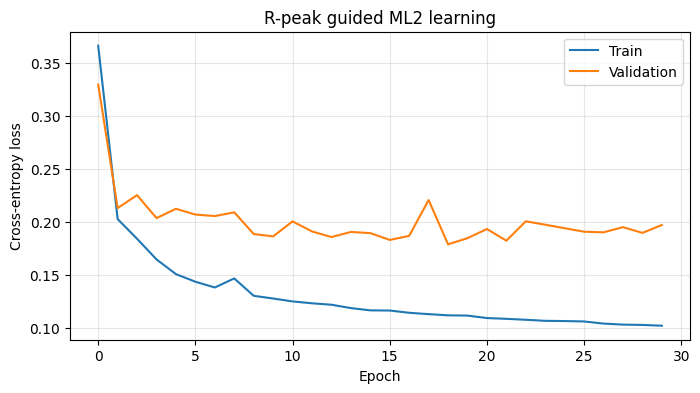

In [40]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.xlabel('Epoch'); plt.ylabel('Cross-entropy loss'); plt.title('R-peak guided ML2 learning')
plt.grid(alpha=0.3); plt.legend(); plt.show()


## R1 QTDB validation predictions

In [41]:
# model.load_state_dict(torch.load(R6_MODEL_SAVE_PATH, map_location=device))
model.eval()
all_predictions, all_labels = [], []
with torch.no_grad():
    for batch_ecg, batch_labels in val_loader:
        predicted = model(batch_ecg.to(device)).argmax(dim=2).cpu().numpy()
        all_predictions.append(predicted)
        all_labels.append(batch_labels.numpy())
all_predictions = np.concatenate(all_predictions)
all_labels = np.concatenate(all_labels)

print(classification_report(all_labels.ravel(), all_predictions.ravel(),
                            labels=[0, 1, 2], target_names=['Background', 'P Wave', 'T Wave'], digits=4, zero_division=0))
p_f1, t_f1 = f1_score(all_labels.ravel(), all_predictions.ravel(), labels=[1, 2], average=None, zero_division=0)
macro_f1 = f1_score(all_labels.ravel(), all_predictions.ravel(), labels=[0, 1, 2], average='macro', zero_division=0)
print(f'P F1: {p_f1:.4f} | T F1: {t_f1:.4f} | Macro F1: {macro_f1:.4f}')


              precision    recall  f1-score   support

  Background     0.9433    0.9587    0.9510   5575033
      P Wave     0.9029    0.8508    0.8761    985295
      T Wave     0.8992    0.8807    0.8899   1647312

    accuracy                         0.9301   8207640
   macro avg     0.9151    0.8967    0.9056   8207640
weighted avg     0.9296    0.9301    0.9297   8207640

P F1: 0.8761 | T F1: 0.8899 | Macro F1: 0.9056


## Shared evaluation methods

The following helpers calculate wave-boundary error in milliseconds. They are reused by R1–R6 evaluation cells.


In [42]:
def first_and_last(labels, wave_class):
    points = np.flatnonzero(labels == wave_class)
    return (points[0], points[-1]) if len(points) else (np.nan, np.nan)

def boundary_error_ms(y_true, y_pred, fs=250.0):
    errors = {name: [] for name in ['P onset', 'P offset', 'T onset', 'T offset']}
    for truth, pred in zip(y_true, y_pred):
        for wave_class, onset_name, offset_name in [(1, 'P onset', 'P offset'), (2, 'T onset', 'T offset')]:
            true_on, true_off = first_and_last(truth, wave_class)
            pred_on, pred_off = first_and_last(pred, wave_class)
            if not np.isnan(true_on) and not np.isnan(pred_on):
                errors[onset_name].append(abs(pred_on - true_on) / fs * 1000)
                errors[offset_name].append(abs(pred_off - true_off) / fs * 1000)
    return {name: np.mean(values) if values else np.nan for name, values in errors.items()}

# QTDB records use 250 Hz. This is sample error turned into ms.
boundary_errors = boundary_error_ms(all_labels, all_predictions)
pd.Series(boundary_errors, name='mean absolute error (ms)').to_frame()


,mean absolute error (ms)
P onset,54.896921
P offset,64.134435
T onset,85.172525
T offset,88.199047


## R1 QTDB evaluation — per-record results and baseline comparison

In [43]:
record_rows = []
for record_name in np.unique(val_record_ids):
    mask = val_record_ids == record_name
    record_rows.append({
        'record': record_name,
        'P F1': f1_score(all_labels[mask].ravel(), all_predictions[mask].ravel(), labels=[1], average='macro', zero_division=0),
        'T F1': f1_score(all_labels[mask].ravel(), all_predictions[mask].ravel(), labels=[2], average='macro', zero_division=0),
        'macro F1': f1_score(all_labels[mask].ravel(), all_predictions[mask].ravel(), labels=[0, 1, 2], average='macro', zero_division=0),
    })
record_df = pd.DataFrame(record_rows).sort_values('macro F1')
display(record_df.head(10))
worst_record = record_df.iloc[0]
print(f"Worst record: {worst_record['record']} | macro F1: {worst_record['macro F1']:.4f}")

comparison = pd.DataFrame([
    {'model': 'Old ML2 (fill from baseline run)', 'P F1': np.nan, 'T F1': np.nan, 'Macro F1': np.nan, 'Worst record': '', 'Boundary error (ms)': np.nan},
    {'model': 'R-centred ML2', 'P F1': p_f1, 'T F1': t_f1, 'Macro F1': macro_f1,
     'Worst record': worst_record['record'], 'Boundary error (ms)': np.nanmean(list(boundary_errors.values()))},
])
display(comparison)


,record,P F1,T F1,macro F1
7,sel43,0.676367,0.134156,0.554779
6,sel40,0.131894,0.841511,0.611944
11,sele0107,0.375511,0.926947,0.758302
10,sel891,0.617779,0.890780,0.807843
8,sel44,0.833030,0.783790,0.815893
12,sele0111,0.798590,0.863417,0.869892
1,sel16265,0.712271,0.942919,0.871354
13,sele0112,0.756331,0.897018,0.872056
20,sele0704,0.976449,0.809421,0.907682
0,sel116,0.935136,0.939502,0.947699


Worst record: sel43 | macro F1: 0.5548


,model,P F1,T F1,Macro F1,Worst record,Boundary error (ms)
0,Old ML2 (fill from baseline run),NaN,NaN,NaN,,NaN
1,R-centred ML2,0.876068,0.889877,0.905633,sel43,73.100732


## R1 QTDB qualitative inspection

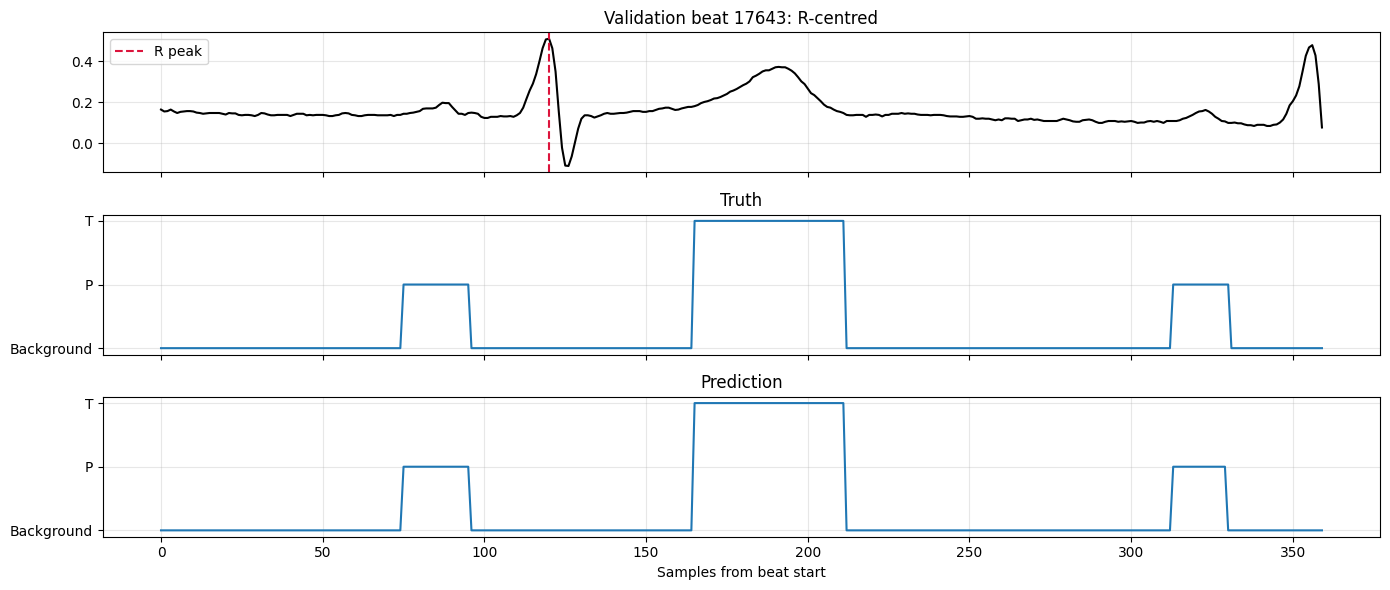

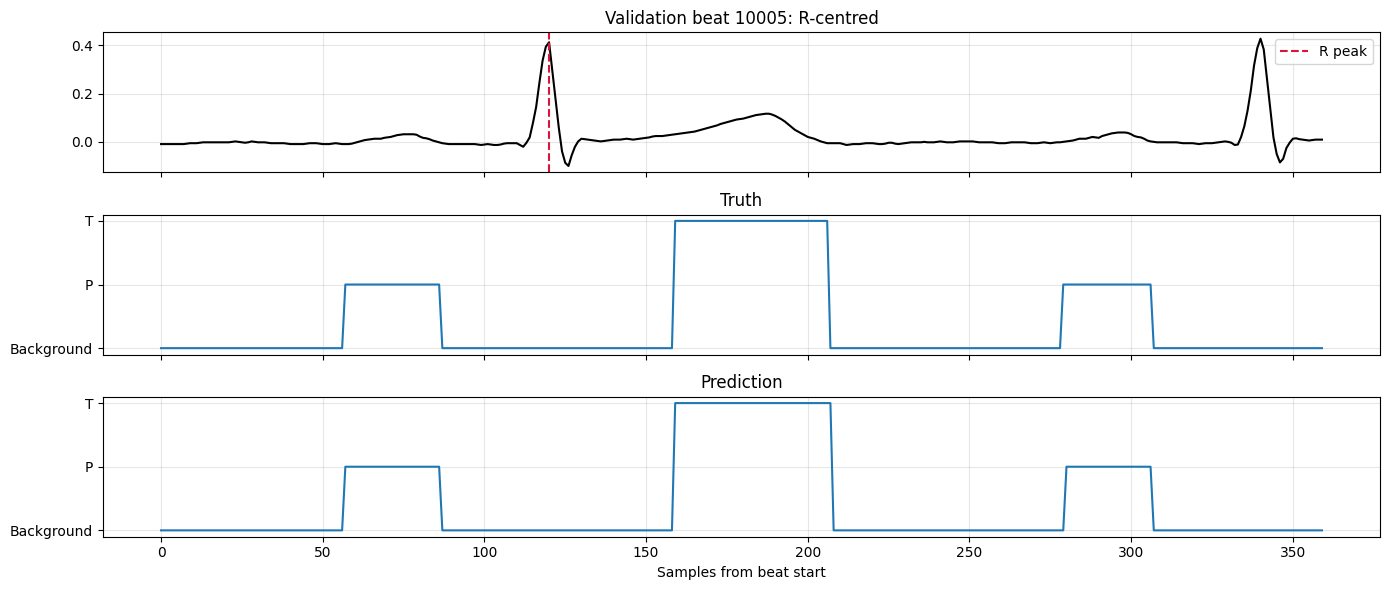

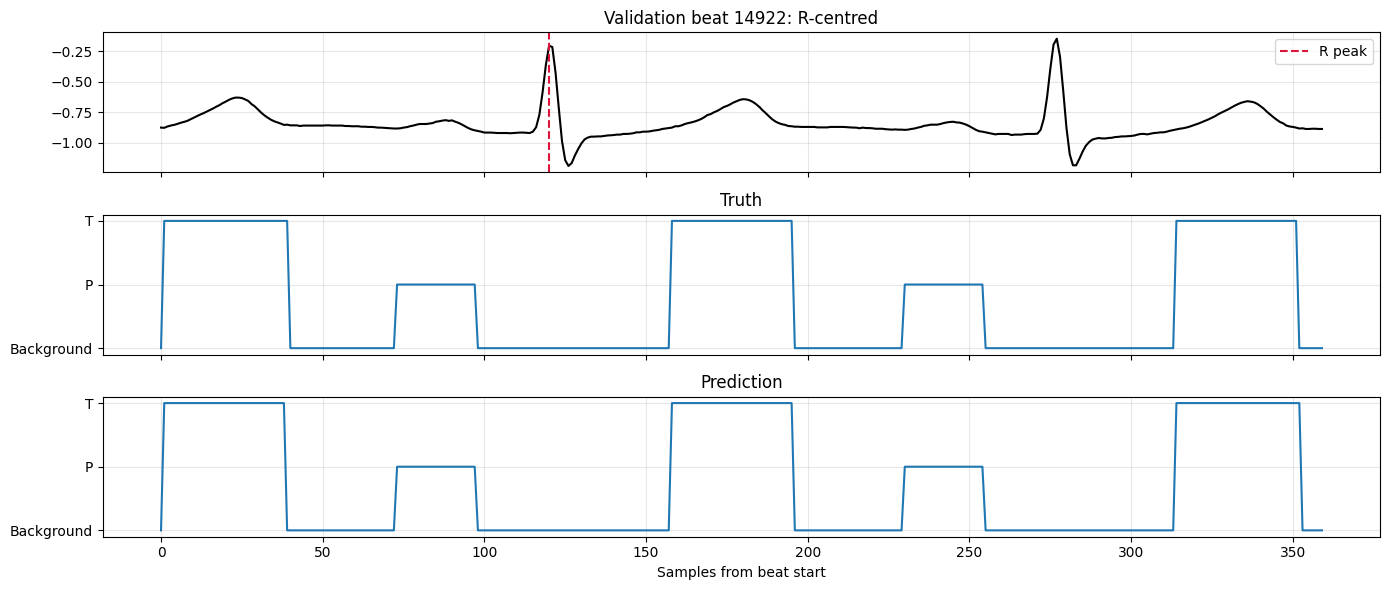

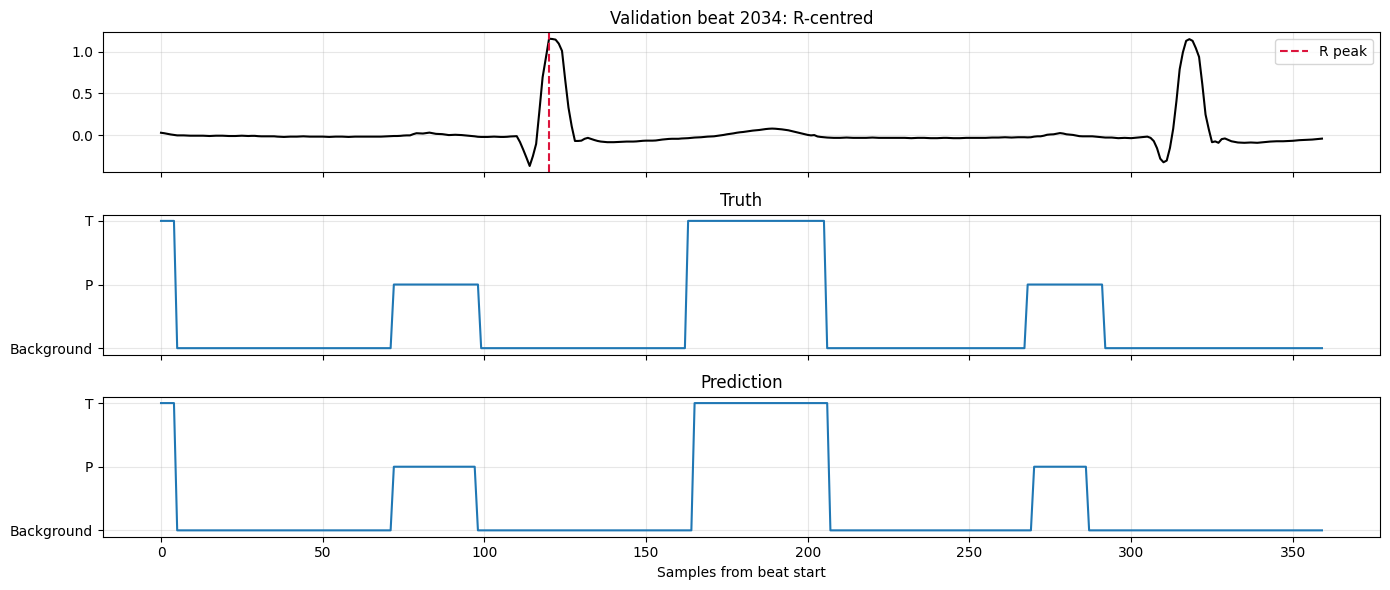

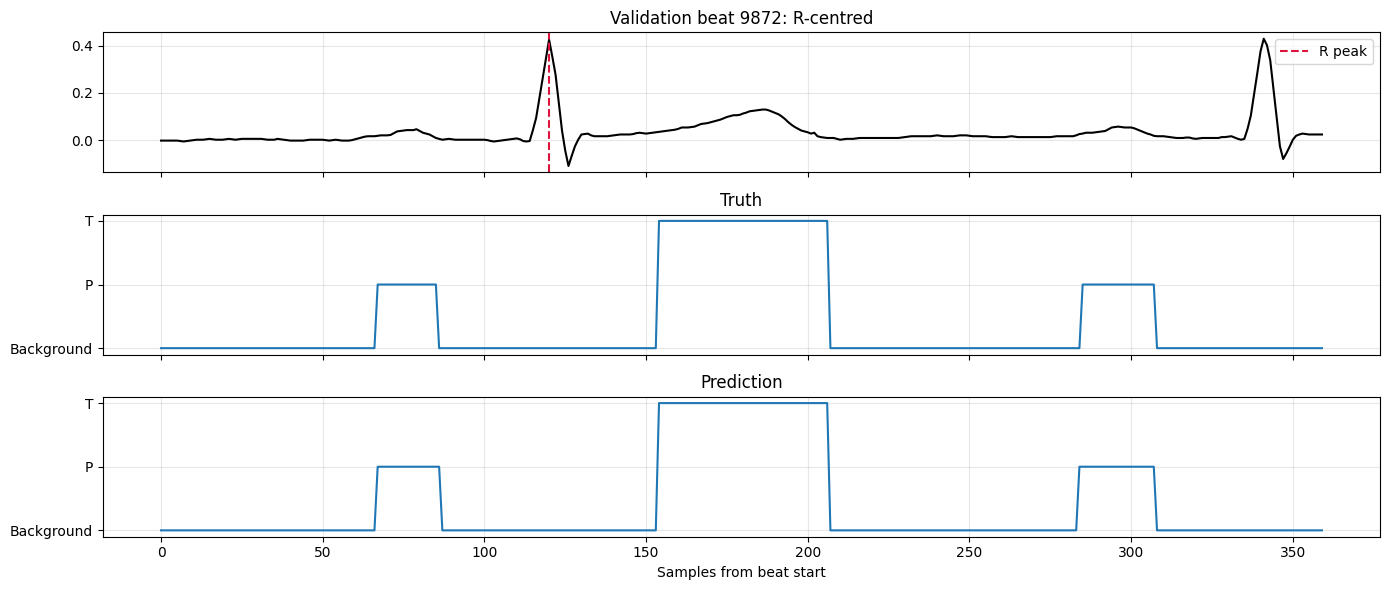

In [44]:
# Look at a few R-centred validation beats. R is at sample PRE.
rng = np.random.default_rng(42)
for idx in rng.choice(len(val_dataset), size=min(5, len(val_dataset)), replace=False):
    signal = val_dataset[idx][0].squeeze().numpy()
    truth, pred = all_labels[idx], all_predictions[idx]
    x = np.arange(BEAT_LENGTH)
    fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
    axes[0].plot(x, signal, color='black'); axes[0].axvline(PRE, color='crimson', ls='--', label='R peak'); axes[0].legend()
    axes[0].set_title(f'Validation beat {idx}: R-centred')
    axes[1].plot(x, truth); axes[1].set_yticks([0, 1, 2]); axes[1].set_yticklabels(['Background', 'P', 'T']); axes[1].set_title('Truth')
    axes[2].plot(x, pred); axes[2].set_yticks([0, 1, 2]); axes[2].set_yticklabels(['Background', 'P', 'T']); axes[2].set_title('Prediction')
    for ax in axes: ax.grid(alpha=0.3)
    axes[2].set_xlabel('Samples from beat start'); plt.tight_layout(); plt.show()


## R1 external-test preprocessing — LUDB

LUDB is held out from R1 training. Signals and annotations are resampled from 500 Hz to 250 Hz, then lead II is converted into R-centred beats.


In [45]:
# LUDB external test. Run this only after the notebook train/data cells.
# LUDB is never used for training. It is a hold-out test.
from scipy.signal import resample_poly

LUDB_DIR = Path(
    "/kaggle/input/datasets/vrishankamembal/ludb-1-0-1/"
    "lobachevsky-university-electrocardiography-database-1.0.1/data"
)
assert LUDB_DIR.exists(), f'Missing LUDB folder: {LUDB_DIR}'
assert 'train_mean' in globals() and 'train_std' in globals(), 'Run the QTDB training/data cells first.'

def ludb_labels_at_250(annotation, original_length):
    """LUDB annotation -> 0 Background, 1 P, 2 QRS, 3 T, at 250 Hz."""
    labels = np.zeros(round(original_length / 2), dtype=np.int64)
    start, kind = None, None
    for sample, symbol in zip(annotation.sample, annotation.symbol):
        if symbol == '(':
            start, kind = sample, None
        elif symbol == 'p':
            kind = 1
        elif symbol == 'N':
            kind = 2
        elif symbol == 't':
            kind = 3
        elif symbol == ')' and start is not None and kind is not None:
            left, right = round(start / 2), round(sample / 2)
            labels[left:right + 1] = kind
            start, kind = None, None
    return labels

def wave_intervals(labels, wave_class):
    mask = labels == wave_class
    edges = np.diff(np.r_[False, mask, False].astype(int))
    return list(zip(np.flatnonzero(edges == 1), np.flatnonzero(edges == -1) - 1))

def boundary_errors_ms(y_true, y_pred, class_map, fs=250):
    errors = {f'{name} onset': [] for name in class_map.values()}
    errors.update({f'{name} offset': [] for name in class_map.values()})
    missed = {name: 0 for name in class_map.values()}
    for truth, pred in zip(y_true, y_pred):
        for wave_class, name in class_map.items():
            predicted = wave_intervals(pred, wave_class)
            for start, end in wave_intervals(truth, wave_class):
                overlaps = [max(0, min(end, p_end) - max(start, p_start) + 1)
                            for p_start, p_end in predicted]
                if not overlaps or max(overlaps) == 0:
                    missed[name] += 1
                    continue
                p_start, p_end = predicted[int(np.argmax(overlaps))]
                errors[f'{name} onset'].append(abs(p_start - start) / fs * 1000)
                errors[f'{name} offset'].append(abs(p_end - end) / fs * 1000)
    return {key: np.mean(value) if value else np.nan for key, value in errors.items()}, missed

ludb_x, ludb_y, ludb_record_ids = [], [], []
for header in sorted(LUDB_DIR.glob('*.hea')):
    record_name = header.stem
    path = str(header.with_suffix(''))
    record = wfdb.rdrecord(path)
    lead = record.sig_name.index('ii')  # QTDB MLII matches LUDB lead II.
    signal = resample_poly(record.p_signal[:, lead].astype(np.float32), up=1, down=2)
    annotation = wfdb.rdann(path, 'ii')
    labels = ludb_labels_at_250(annotation, len(record.p_signal))
    size = min(len(signal), len(labels))
    signal, labels = signal[:size], labels[:size]
    labels = to_pt_labels(labels)  # QRS is background for this model.
    r_peaks = pan_tompkins_r_peaks(signal, 250.0)
    X, Y, _ = create_r_centered_beats(signal, labels, r_peaks)
    if len(X):
        ludb_x.append(X); ludb_y.append(Y); ludb_record_ids.extend([record_name] * len(X))

X_ludb = np.concatenate(ludb_x)
Y_ludb = np.concatenate(ludb_y)
ludb_record_ids = np.asarray(ludb_record_ids)
X_ludb = (X_ludb - train_mean) / train_std
print(f'LUDB external test: {len(np.unique(ludb_record_ids))} records, {len(X_ludb)} R-centred beats')



LUDB external test: 200 records, 1904 R-centred beats


## R1 external evaluation — LUDB

In [47]:
# Score saved QTDB model on LUDB. No fitting here.
model = RPeakGuidedML2().to(device)
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()

ludb_predictions = []
with torch.no_grad():
    for start in range(0, len(X_ludb), BATCH_SIZE):
        batch = torch.tensor(X_ludb[start:start + BATCH_SIZE], dtype=torch.float32).unsqueeze(1).to(device)
        ludb_predictions.append(model(batch).argmax(dim=2).cpu().numpy())
ludb_predictions = np.concatenate(ludb_predictions)

p_f1_ludb, t_f1_ludb = f1_score(Y_ludb.ravel(), ludb_predictions.ravel(),
                                labels=[1, 2], average=None, zero_division=0)
macro_f1_ludb = f1_score(Y_ludb.ravel(), ludb_predictions.ravel(),
                         labels=[0, 1, 2], average='macro', zero_division=0)
errors_ludb, missed_ludb = boundary_errors_ms(Y_ludb, ludb_predictions, {1: 'P', 2: 'T'})
print(classification_report(Y_ludb.ravel(), ludb_predictions.ravel(),
                            labels=[0, 1, 2],
                            target_names=['Background', 'P Wave', 'T Wave'],
                            digits=4, zero_division=0))
print(f'LUDB P F1: {p_f1_ludb:.4f} | T F1: {t_f1_ludb:.4f} | Macro F1: {macro_f1_ludb:.4f}')
display(pd.Series(errors_ludb, name='boundary MAE (ms)').to_frame())
print('Missed true waves:', missed_ludb)

record_rows = []
for record_name in np.unique(ludb_record_ids):
    mask = ludb_record_ids == record_name
    record_rows.append({'record': record_name,
        'P F1': f1_score(Y_ludb[mask].ravel(), ludb_predictions[mask].ravel(), labels=[1], average='macro', zero_division=0),
        'T F1': f1_score(Y_ludb[mask].ravel(), ludb_predictions[mask].ravel(), labels=[2], average='macro', zero_division=0),
        'macro F1': f1_score(Y_ludb[mask].ravel(), ludb_predictions[mask].ravel(), labels=[0, 1, 2], average='macro', zero_division=0)})
ludb_record_results = pd.DataFrame(record_rows).sort_values('macro F1')
display(ludb_record_results.head(10))



              precision    recall  f1-score   support

  Background     0.9239    0.9123    0.9180    509929
      P Wave     0.7516    0.8245    0.7864     75779
      T Wave     0.7459    0.7389    0.7424     99732

    accuracy                         0.8773    685440
   macro avg     0.8072    0.8252    0.8156    685440
weighted avg     0.8789    0.8773    0.8779    685440

LUDB P F1: 0.7864 | T F1: 0.7424 | Macro F1: 0.8156


,boundary MAE (ms)
P onset,10.357798
T onset,24.816717
P offset,10.033639
T offset,15.618633


Missed true waves: {'P': 97, 'T': 355}


,record,P F1,T F1,macro F1
11,109,0.000000,0.007890,0.285388
30,126,0.075710,0.000000,0.307759
25,121,0.201729,0.132877,0.354047
129,35,0.000000,0.314996,0.373764
3,101,0.000000,0.374915,0.383079
132,38,0.000000,0.401447,0.406269
13,110,0.000000,0.372430,0.414358
31,127,0.000000,0.325926,0.419798
148,52,0.000000,0.546619,0.422636
6,104,0.000000,0.449704,0.443084


# R2 — R-centred beats with weighted Focal Loss

R2 keeps R1 data, model, batch size, learning rate, and epochs. The only modeling change is class-weighted Focal Loss.


## R2 model, loss, training function, and training diagnostics

R2 class counts: [20200669  3844987  7314304]
R2 class weights: tensor([0.5175, 2.7187, 1.4292], device='cuda:0')
Only R1 -> R2 change: CrossEntropy becomes weighted Focal Loss.
R2 epoch 01/30: train 0.2045, val 0.1075
R2 epoch 02/30: train 0.0908, val 0.0909
R2 epoch 03/30: train 0.0941, val 0.0807
R2 epoch 04/30: train 0.0668, val 0.0874
R2 epoch 05/30: train 0.0580, val 0.0784
R2 epoch 06/30: train 0.0533, val 0.0844
R2 epoch 07/30: train 0.0504, val 0.0699
R2 epoch 08/30: train 0.0489, val 0.0723
R2 epoch 09/30: train 0.0456, val 0.0796
R2 epoch 10/30: train 0.0459, val 0.0678
R2 epoch 11/30: train 0.0431, val 0.0617
R2 epoch 12/30: train 0.0428, val 0.1045
R2 epoch 13/30: train 0.0415, val 0.0762
R2 epoch 14/30: train 0.0397, val 0.0674
R2 epoch 15/30: train 0.0392, val 0.0662
R2 epoch 16/30: train 0.0378, val 0.0659
R2 epoch 17/30: train 0.0410, val 0.1735
R2 epoch 18/30: train 0.0435, val 0.0675
R2 epoch 19/30: train 0.0384, val 0.0681
R2 epoch 20/30: train 0.0363, val 0.0670
R2

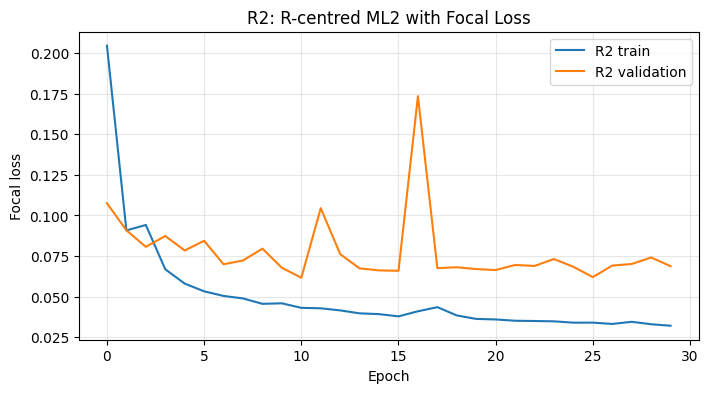

In [48]:
import torch.nn.functional as F

# R2: only loss changes from R1.
R2_MODEL_SAVE_PATH = 'best_ml2_rpeak_guided_focal.pth'

class FocalLoss(nn.Module):
    """Same focal loss form used in ML2 baseline focal test."""
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        return (((1 - pt) ** self.gamma) * ce_loss).mean()

# Same inverse-frequency weighting rule as old ML2. Classes: Background, P, T.
r2_class_counts = np.bincount(Y_train.ravel(), minlength=3)
r2_class_weights = torch.tensor(
    len(Y_train.ravel()) / (3 * r2_class_counts), dtype=torch.float32, device=device
)
focal_model = RPeakGuidedML2().to(device)
focal_criterion = FocalLoss(alpha=r2_class_weights, gamma=2.0)
focal_optimizer = torch.optim.Adam(focal_model.parameters(), lr=1e-3)

print('R2 class counts:', r2_class_counts)
print('R2 class weights:', r2_class_weights)
print('Only R1 -> R2 change: CrossEntropy becomes weighted Focal Loss.')

def run_r2_epoch(loader, train=False):
    focal_model.train(train)
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for batch_ecg, batch_labels in loader:
            batch_ecg, batch_labels = batch_ecg.to(device), batch_labels.to(device)
            logits = focal_model(batch_ecg).permute(0, 2, 1)
            loss = focal_criterion(logits, batch_labels)
            if train:
                focal_optimizer.zero_grad()
                loss.backward()
                focal_optimizer.step()
            total_loss += loss.item()
    return total_loss / len(loader)

r2_train_losses, r2_val_losses = [], []
r2_best_val_loss, r2_best_epoch = float('inf'), 0
for epoch in range(NUM_EPOCHS):
    train_loss = run_r2_epoch(train_loader, train=True)
    val_loss = run_r2_epoch(val_loader)
    r2_train_losses.append(train_loss)
    r2_val_losses.append(val_loss)
    print(f'R2 epoch {epoch + 1:02d}/{NUM_EPOCHS}: train {train_loss:.4f}, val {val_loss:.4f}')
    if val_loss < r2_best_val_loss:
        r2_best_val_loss, r2_best_epoch = val_loss, epoch + 1
        torch.save(focal_model.state_dict(), R2_MODEL_SAVE_PATH)
print(f'R2 best: epoch {r2_best_epoch}, val loss {r2_best_val_loss:.4f}; saved {R2_MODEL_SAVE_PATH}')

plt.figure(figsize=(8, 4))
plt.plot(r2_train_losses, label='R2 train')
plt.plot(r2_val_losses, label='R2 validation')
plt.xlabel('Epoch'); plt.ylabel('Focal loss'); plt.title('R2: R-centred ML2 with Focal Loss')
plt.grid(alpha=0.3); plt.legend(); plt.show()



## R2 QTDB and LUDB evaluation

In [49]:
# R2 QTDB hold-out score. Same record split as R1.
focal_model.load_state_dict(torch.load(R2_MODEL_SAVE_PATH, map_location=device))
focal_model.eval()
r2_predictions, r2_labels = [], []
with torch.no_grad():
    for batch_ecg, batch_labels in val_loader:
        r2_predictions.append(focal_model(batch_ecg.to(device)).argmax(dim=2).cpu().numpy())
        r2_labels.append(batch_labels.numpy())
r2_predictions, r2_labels = np.concatenate(r2_predictions), np.concatenate(r2_labels)
r2_p_f1, r2_t_f1 = f1_score(r2_labels.ravel(), r2_predictions.ravel(), labels=[1, 2], average=None, zero_division=0)
r2_macro_f1 = f1_score(r2_labels.ravel(), r2_predictions.ravel(), labels=[0, 1, 2], average='macro', zero_division=0)
r2_boundary_errors = boundary_error_ms(r2_labels, r2_predictions)
print(f'R2 QTDB: P F1 {r2_p_f1:.4f} | T F1 {r2_t_f1:.4f} | Macro F1 {r2_macro_f1:.4f}')
display(pd.Series(r2_boundary_errors, name='R2 boundary MAE (ms)').to_frame())

# R2 LUDB hold-out score. Run LUDB data and R1 score cells first.
assert 'X_ludb' in globals(), 'Run the LUDB data cell first.'
r1_ludb_metrics = ({
    'P F1': p_f1_ludb, 'T F1': t_f1_ludb, 'Macro F1': macro_f1_ludb,
    'Boundary MAE (ms)': np.nanmean(list(errors_ludb.values()))
} if 'p_f1_ludb' in globals() else None)

r2_ludb_predictions = []
with torch.no_grad():
    for start in range(0, len(X_ludb), BATCH_SIZE):
        batch = torch.tensor(X_ludb[start:start + BATCH_SIZE], dtype=torch.float32).unsqueeze(1).to(device)
        r2_ludb_predictions.append(focal_model(batch).argmax(dim=2).cpu().numpy())
r2_ludb_predictions = np.concatenate(r2_ludb_predictions)
r2_ludb_p_f1, r2_ludb_t_f1 = f1_score(Y_ludb.ravel(), r2_ludb_predictions.ravel(), labels=[1, 2], average=None, zero_division=0)
r2_ludb_macro_f1 = f1_score(Y_ludb.ravel(), r2_ludb_predictions.ravel(), labels=[0, 1, 2], average='macro', zero_division=0)
r2_ludb_errors, r2_ludb_missed = boundary_errors_ms(Y_ludb, r2_ludb_predictions, {1: 'P', 2: 'T'})
print(f'R2 LUDB: P F1 {r2_ludb_p_f1:.4f} | T F1 {r2_ludb_t_f1:.4f} | Macro F1 {r2_ludb_macro_f1:.4f}')
display(pd.Series(r2_ludb_errors, name='R2 boundary MAE (ms)').to_frame())
print('R2 missed true waves:', r2_ludb_missed)

r2_ludb_rows = []
for record_name in np.unique(ludb_record_ids):
    mask = ludb_record_ids == record_name
    r2_ludb_rows.append({'record': record_name,
        'P F1': f1_score(Y_ludb[mask].ravel(), r2_ludb_predictions[mask].ravel(), labels=[1], average='macro', zero_division=0),
        'T F1': f1_score(Y_ludb[mask].ravel(), r2_ludb_predictions[mask].ravel(), labels=[2], average='macro', zero_division=0),
        'macro F1': f1_score(Y_ludb[mask].ravel(), r2_ludb_predictions[mask].ravel(), labels=[0, 1, 2], average='macro', zero_division=0)})
display(pd.DataFrame(r2_ludb_rows).sort_values('macro F1').head(10))

r2_ludb_metrics = {'P F1': r2_ludb_p_f1, 'T F1': r2_ludb_t_f1,
                   'Macro F1': r2_ludb_macro_f1,
                   'Boundary MAE (ms)': np.nanmean(list(r2_ludb_errors.values()))}
comparison_rows = []
if r1_ludb_metrics is not None:
    comparison_rows.append({'experiment': 'R1: CrossEntropy', **r1_ludb_metrics})
comparison_rows.append({'experiment': 'R2: weighted Focal Loss', **r2_ludb_metrics})
display(pd.DataFrame(comparison_rows))


R2 QTDB: P F1 0.8132 | T F1 0.7904 | Macro F1 0.8270


,R2 boundary MAE (ms)
P onset,60.335195
P offset,134.361373
T onset,236.158666
T offset,122.782368


R2 LUDB: P F1 0.7393 | T F1 0.6214 | Macro F1 0.7290


,R2 boundary MAE (ms)
P onset,9.341725
T onset,23.451800
P offset,7.906701
T offset,60.209059


R2 missed true waves: {'P': 12, 'T': 69}


,record,P F1,T F1,macro F1
11,109,0.000000,0.240000,0.283704
148,52,0.000000,0.441161,0.291002
140,45,0.000000,0.475896,0.317886
193,93,0.000000,0.460494,0.334931
178,8,0.000000,0.451186,0.343501
128,34,0.000000,0.396442,0.349975
6,104,0.000000,0.450790,0.369938
5,103,0.000000,0.578437,0.382552
30,126,0.397086,0.000000,0.382808
14,111,0.000000,0.456993,0.387291


,experiment,P F1,T F1,Macro F1,Boundary MAE (ms)
0,R1: CrossEntropy,0.786361,0.742387,0.815599,15.206697
1,R2: weighted Focal Loss,0.739301,0.621438,0.728988,25.227321


# R3 — R-centred beats with unweighted Focal Loss

R3 keeps the R1 data, model, batch size, learning rate, and epochs, but replaces cross-entropy with unweighted Focal Loss (gamma = 2).


## R3 model, loss, training function, and training diagnostics

R3 change from R1: CrossEntropy -> unweighted Focal Loss only.
R3 epoch 01/30: train 0.1237, val 0.0774
R3 epoch 02/30: train 0.0707, val 0.0791
R3 epoch 03/30: train 0.0597, val 0.0679
R3 epoch 04/30: train 0.0505, val 0.0660
R3 epoch 05/30: train 0.0566, val 0.0625
R3 epoch 06/30: train 0.0456, val 0.0785
R3 epoch 07/30: train 0.0434, val 0.0636
R3 epoch 08/30: train 0.0415, val 0.0676
R3 epoch 09/30: train 0.0402, val 0.0583
R3 epoch 10/30: train 0.0388, val 0.0573
R3 epoch 11/30: train 0.0379, val 0.0636
R3 epoch 12/30: train 0.0372, val 0.0594
R3 epoch 13/30: train 0.0362, val 0.0604
R3 epoch 14/30: train 0.0356, val 0.0637
R3 epoch 15/30: train 0.0406, val 0.0640
R3 epoch 16/30: train 0.0346, val 0.0650
R3 epoch 17/30: train 0.0342, val 0.0609
R3 epoch 18/30: train 0.0337, val 0.0647
R3 epoch 19/30: train 0.0334, val 0.0620
R3 epoch 20/30: train 0.0328, val 0.0609
R3 epoch 21/30: train 0.0324, val 0.0639
R3 epoch 22/30: train 0.0326, val 0.0621
R3 epoch 23/30: train 0.0322, val 0

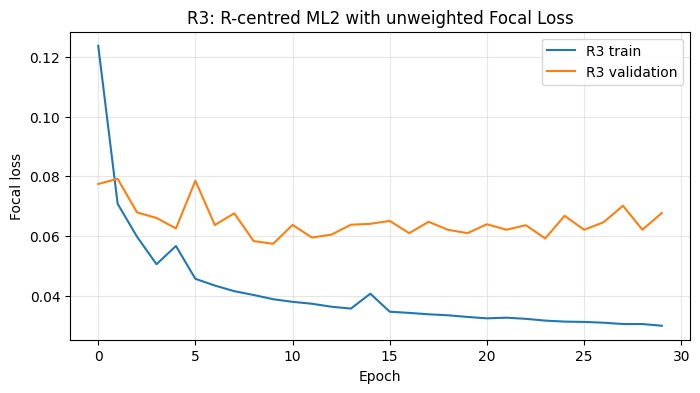

In [50]:
import torch.nn.functional as F

# R3: standard unweighted Focal Loss. No alpha / no class weights.
R3_MODEL_SAVE_PATH = 'best_ml2_rpeak_guided_focal_unweighted.pth'

class UnweightedFocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        return (((1 - pt) ** self.gamma) * ce_loss).mean()

r3_model = RPeakGuidedML2().to(device)
r3_criterion = UnweightedFocalLoss(gamma=2.0)
r3_optimizer = torch.optim.Adam(r3_model.parameters(), lr=1e-3)
print('R3 change from R1: CrossEntropy -> unweighted Focal Loss only.')

def run_r3_epoch(loader, train=False):
    r3_model.train(train)
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for batch_ecg, batch_labels in loader:
            batch_ecg, batch_labels = batch_ecg.to(device), batch_labels.to(device)
            logits = r3_model(batch_ecg).permute(0, 2, 1)
            loss = r3_criterion(logits, batch_labels)
            if train:
                r3_optimizer.zero_grad()
                loss.backward()
                r3_optimizer.step()
            total_loss += loss.item()
    return total_loss / len(loader)

r3_train_losses, r3_val_losses = [], []
r3_best_val_loss, r3_best_epoch = float('inf'), 0
for epoch in range(NUM_EPOCHS):
    train_loss = run_r3_epoch(train_loader, train=True)
    val_loss = run_r3_epoch(val_loader)
    r3_train_losses.append(train_loss)
    r3_val_losses.append(val_loss)
    print(f'R3 epoch {epoch + 1:02d}/{NUM_EPOCHS}: train {train_loss:.4f}, val {val_loss:.4f}')
    if val_loss < r3_best_val_loss:
        r3_best_val_loss, r3_best_epoch = val_loss, epoch + 1
        torch.save(r3_model.state_dict(), R3_MODEL_SAVE_PATH)
print(f'R3 best: epoch {r3_best_epoch}, val loss {r3_best_val_loss:.4f}; saved {R3_MODEL_SAVE_PATH}')

plt.figure(figsize=(8, 4))
plt.plot(r3_train_losses, label='R3 train')
plt.plot(r3_val_losses, label='R3 validation')
plt.xlabel('Epoch'); plt.ylabel('Focal loss'); plt.title('R3: R-centred ML2 with unweighted Focal Loss')
plt.grid(alpha=0.3); plt.legend(); plt.show()



## R3 QTDB and LUDB evaluation

In [51]:
# R3 QTDB hold-out score. Same records as R1 and R2.
r3_model.load_state_dict(torch.load(R3_MODEL_SAVE_PATH, map_location=device))
r3_model.eval()
r3_predictions, r3_labels = [], []
with torch.no_grad():
    for batch_ecg, batch_labels in val_loader:
        r3_predictions.append(r3_model(batch_ecg.to(device)).argmax(dim=2).cpu().numpy())
        r3_labels.append(batch_labels.numpy())
r3_predictions, r3_labels = np.concatenate(r3_predictions), np.concatenate(r3_labels)
r3_p_f1, r3_t_f1 = f1_score(r3_labels.ravel(), r3_predictions.ravel(),
                            labels=[1, 2], average=None, zero_division=0)
r3_macro_f1 = f1_score(r3_labels.ravel(), r3_predictions.ravel(),
                       labels=[0, 1, 2], average='macro', zero_division=0)
r3_boundary_errors = boundary_error_ms(r3_labels, r3_predictions)
print(f'R3 QTDB: P F1 {r3_p_f1:.4f} | T F1 {r3_t_f1:.4f} | Macro F1 {r3_macro_f1:.4f}')
display(pd.Series(r3_boundary_errors, name='R3 boundary MAE (ms)').to_frame())

# R3 LUDB hold-out score. Run LUDB data and R1 score cells first.
assert 'X_ludb' in globals(), 'Run the LUDB data cell first.'
if 'r1_ludb_metrics' not in globals() and 'p_f1_ludb' in globals():
    r1_ludb_metrics = {
        'P F1': p_f1_ludb, 'T F1': t_f1_ludb, 'Macro F1': macro_f1_ludb,
        'Boundary MAE (ms)': np.nanmean(list(errors_ludb.values()))
    }

r3_ludb_predictions = []
with torch.no_grad():
    for start in range(0, len(X_ludb), BATCH_SIZE):
        batch = torch.tensor(X_ludb[start:start + BATCH_SIZE], dtype=torch.float32).unsqueeze(1).to(device)
        r3_ludb_predictions.append(r3_model(batch).argmax(dim=2).cpu().numpy())
r3_ludb_predictions = np.concatenate(r3_ludb_predictions)
r3_ludb_p_f1, r3_ludb_t_f1 = f1_score(Y_ludb.ravel(), r3_ludb_predictions.ravel(),
                                      labels=[1, 2], average=None, zero_division=0)
r3_ludb_macro_f1 = f1_score(Y_ludb.ravel(), r3_ludb_predictions.ravel(),
                            labels=[0, 1, 2], average='macro', zero_division=0)
r3_ludb_errors, r3_ludb_missed = boundary_errors_ms(Y_ludb, r3_ludb_predictions, {1: 'P', 2: 'T'})
print(f'R3 LUDB: P F1 {r3_ludb_p_f1:.4f} | T F1 {r3_ludb_t_f1:.4f} | Macro F1 {r3_ludb_macro_f1:.4f}')
display(pd.Series(r3_ludb_errors, name='R3 boundary MAE (ms)').to_frame())
print('R3 missed true waves:', r3_ludb_missed)

r3_rows = []
for record_name in np.unique(ludb_record_ids):
    mask = ludb_record_ids == record_name
    r3_rows.append({'record': record_name,
        'P F1': f1_score(Y_ludb[mask].ravel(), r3_ludb_predictions[mask].ravel(), labels=[1], average='macro', zero_division=0),
        'T F1': f1_score(Y_ludb[mask].ravel(), r3_ludb_predictions[mask].ravel(), labels=[2], average='macro', zero_division=0),
        'macro F1': f1_score(Y_ludb[mask].ravel(), r3_ludb_predictions[mask].ravel(), labels=[0, 1, 2], average='macro', zero_division=0)})
display(pd.DataFrame(r3_rows).sort_values('macro F1').head(10))

r3_ludb_metrics = {'P F1': r3_ludb_p_f1, 'T F1': r3_ludb_t_f1,
                   'Macro F1': r3_ludb_macro_f1,
                   'Boundary MAE (ms)': np.nanmean(list(r3_ludb_errors.values()))}
comparison_rows = []
if 'r1_ludb_metrics' in globals():
    comparison_rows.append({'experiment': 'R1: CrossEntropy', **r1_ludb_metrics})
if 'r2_ludb_metrics' in globals():
    comparison_rows.append({'experiment': 'R2: weighted Focal Loss', **r2_ludb_metrics})
comparison_rows.append({'experiment': 'R3: unweighted Focal Loss', **r3_ludb_metrics})
display(pd.DataFrame(comparison_rows))


R3 QTDB: P F1 0.8822 | T F1 0.8846 | Macro F1 0.9050


,R3 boundary MAE (ms)
P onset,60.413901
P offset,65.055869
T onset,126.174612
T offset,76.047490


R3 LUDB: P F1 0.7944 | T F1 0.7289 | Macro F1 0.8141


,R3 boundary MAE (ms)
P onset,9.931507
T onset,30.449275
P offset,9.584475
T offset,16.347826


R3 missed true waves: {'P': 85, 'T': 444}


,record,P F1,T F1,macro F1
11,109,0.000000,0.026293,0.290088
30,126,0.142165,0.000000,0.333164
31,127,0.000000,0.105960,0.350783
3,101,0.000000,0.383399,0.387003
13,110,0.000000,0.316049,0.393754
129,35,0.000000,0.378625,0.396593
15,112,0.000000,0.419308,0.410768
25,121,0.314627,0.221465,0.419295
5,103,0.000000,0.581340,0.436849
6,104,0.000000,0.421053,0.438658


,experiment,P F1,T F1,Macro F1,Boundary MAE (ms)
0,R1: CrossEntropy,0.786361,0.742387,0.815599,15.206697
1,R2: weighted Focal Loss,0.739301,0.621438,0.728988,25.227321
2,R3: unweighted Focal Loss,0.794399,0.728940,0.814072,16.578271


## R3 LUDB failure analysis

R3 LUDB failed beats: 409


,beat,record,missed waves
0,10,10,P
1,19,100,T
2,20,100,T
3,21,100,T
4,22,100,T
5,24,101,T
6,26,101,T
7,28,101,T
8,30,101,T
9,31,101,T


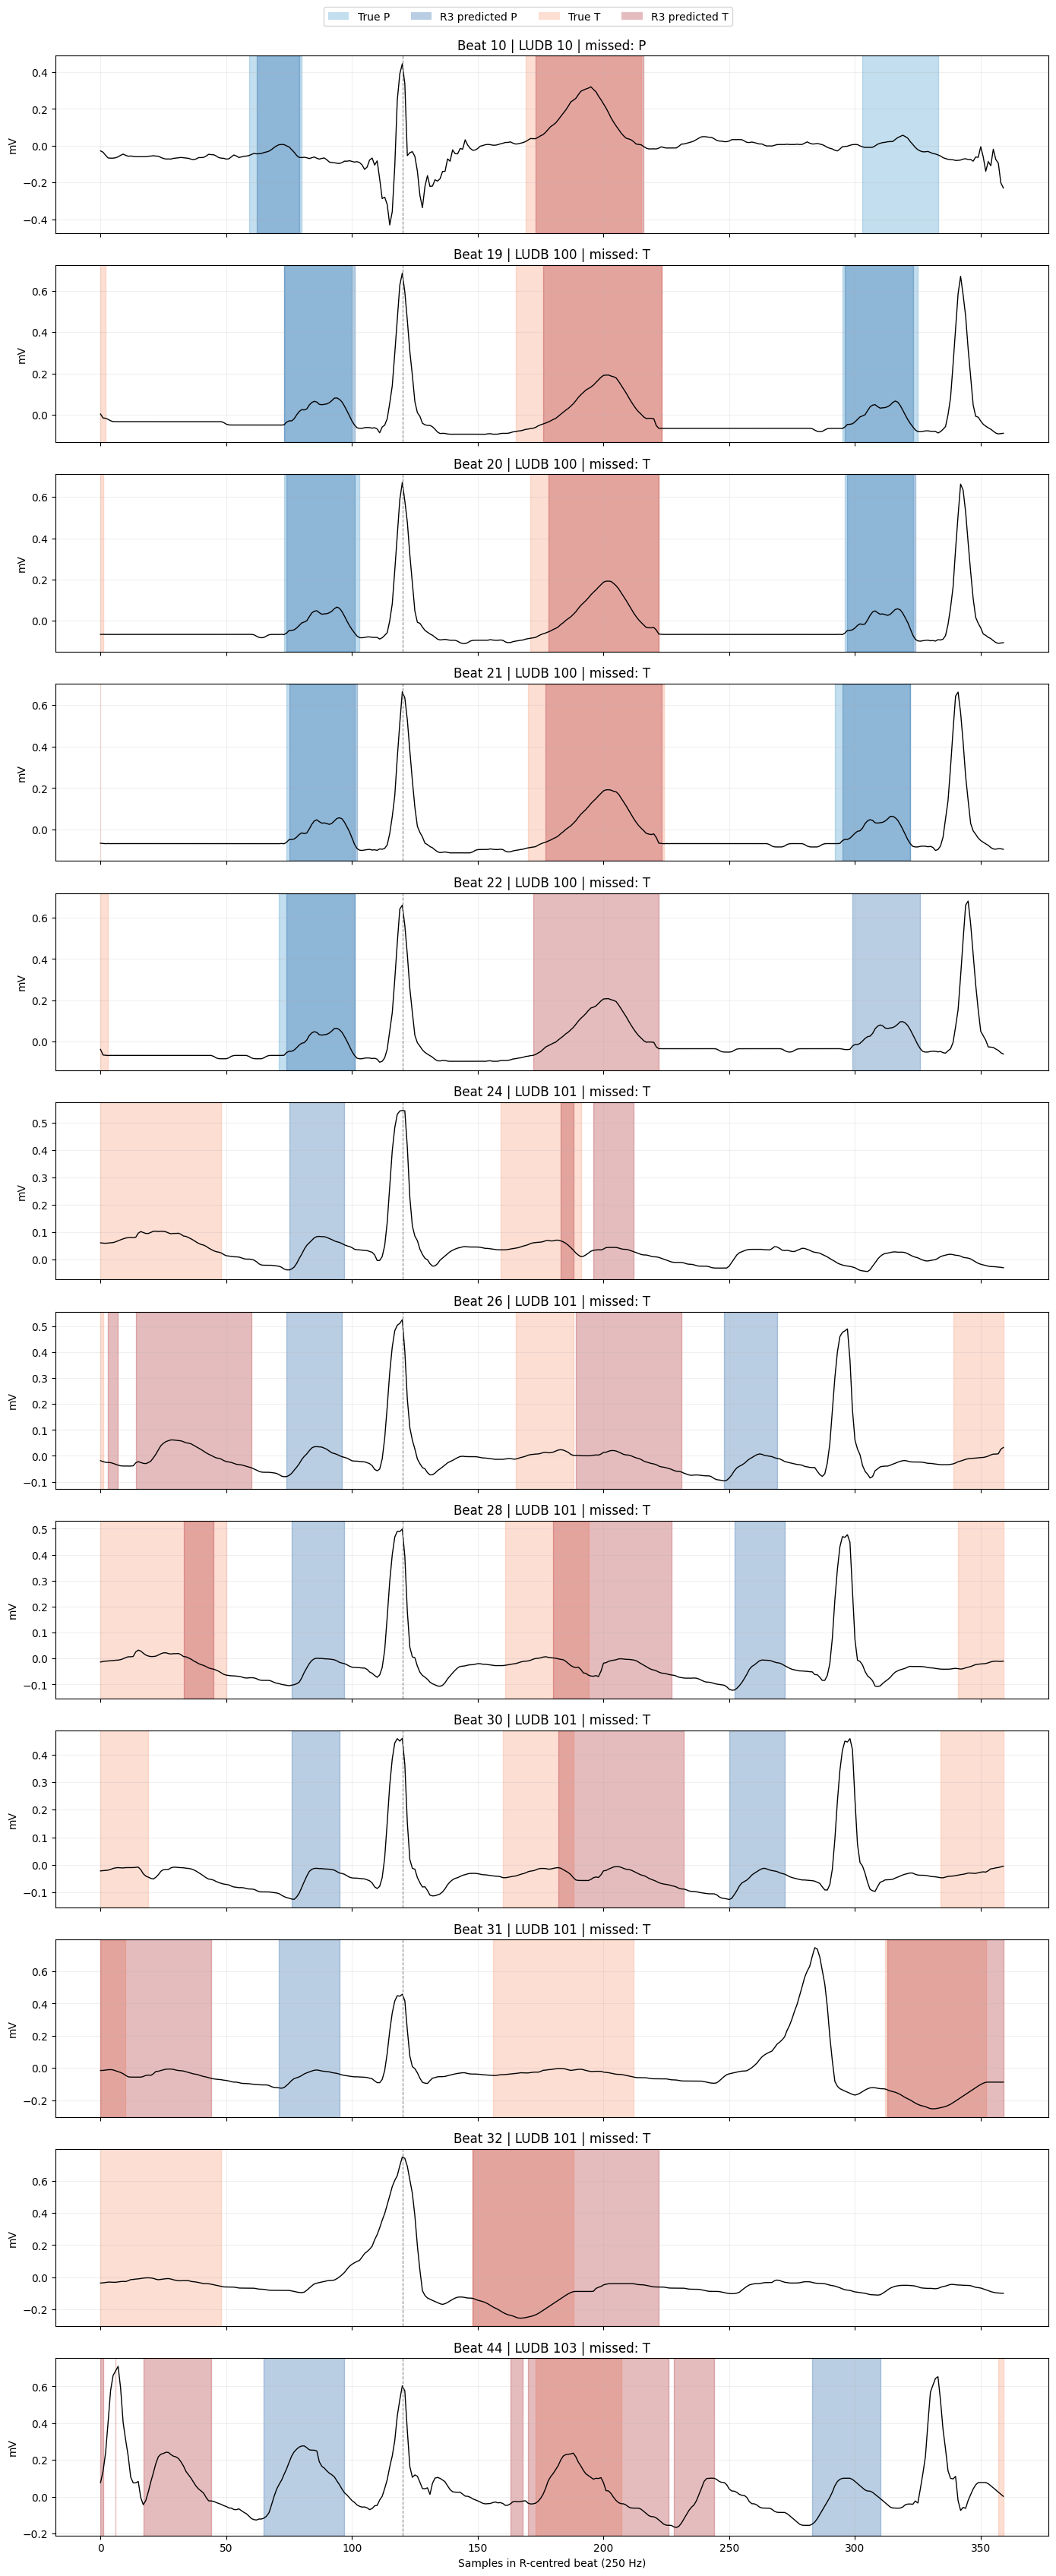

In [53]:
# R3 LUDB failure plots. Run the R3 LUDB score cell first.
# A failed beat has a true P or T region with no overlap from R3 prediction.
from matplotlib.patches import Patch

assert 'r3_ludb_predictions' in globals(), 'Run R3 LUDB score cell first.'

def missed_true_intervals(truth, predicted, wave_class):
    """True intervals that have zero overlap with a same-class prediction."""
    predicted_intervals = wave_intervals(predicted, wave_class)
    missed = []
    for start, end in wave_intervals(truth, wave_class):
        overlaps = [max(0, min(end, p_end) - max(start, p_start) + 1)
                    for p_start, p_end in predicted_intervals]
        if not overlaps or max(overlaps) == 0:
            missed.append((start, end))
    return missed

r3_failed_rows = []
for beat_idx, (truth, predicted) in enumerate(zip(Y_ludb, r3_ludb_predictions)):
    for wave_class, wave_name in ((1, 'P'), (2, 'T')):
        for start, end in missed_true_intervals(truth, predicted, wave_class):
            r3_failed_rows.append({'beat': beat_idx, 'record': ludb_record_ids[beat_idx],
                                   'missed wave': wave_name, 'start': start, 'end': end})

if r3_failed_rows:
    r3_failed_beats = (pd.DataFrame(r3_failed_rows)
                       .groupby(['beat', 'record'], as_index=False)['missed wave']
                       .agg(lambda waves: ', '.join(sorted(set(waves))))
                       .rename(columns={'missed wave': 'missed waves'}))
else:
    r3_failed_beats = pd.DataFrame(columns=['beat', 'record', 'missed waves'])
print(f'R3 LUDB failed beats: {len(r3_failed_beats)}')
display(r3_failed_beats.head(12))

N_FAILED_BEATS_TO_PLOT = 12  # Raise this to see more failed beats.
plot_beats = r3_failed_beats.head(N_FAILED_BEATS_TO_PLOT)
if plot_beats.empty:
    print('No R3 LUDB P/T misses found.')
else:
    fig, axes = plt.subplots(len(plot_beats), 1, figsize=(14, 2.8 * len(plot_beats)), sharex=True)
    axes = np.atleast_1d(axes)
    region_style = {
        1: ('P', '#6baed6', '#08519c'),
        2: ('T', '#fcae91', '#a50f15'),
    }
    for ax, (_, row) in zip(axes, plot_beats.iterrows()):
        beat_idx = int(row['beat'])
        ecg = X_ludb[beat_idx] * train_std + train_mean  # Undo train normalization.
        ax.plot(ecg, color='black', lw=1, label='ECG')
        for wave_class, (wave_name, truth_color, pred_color) in region_style.items():
            for start, end in wave_intervals(Y_ludb[beat_idx], wave_class):
                ax.axvspan(start, end, color=truth_color, alpha=0.40)
            for start, end in wave_intervals(r3_ludb_predictions[beat_idx], wave_class):
                ax.axvspan(start, end, color=pred_color, alpha=0.28)
        ax.axvline(PRE, color='gray', ls='--', lw=0.8, label='R peak')
        ax.set_ylabel('mV')
        ax.set_title(f"Beat {beat_idx} | LUDB {row['record']} | missed: {row['missed waves']}")
        ax.grid(alpha=0.2)
    axes[-1].set_xlabel('Samples in R-centred beat (250 Hz)')
    fig.legend(handles=[
        Patch(facecolor='#6baed6', alpha=0.40, label='True P'),
        Patch(facecolor='#08519c', alpha=0.28, label='R3 predicted P'),
        Patch(facecolor='#fcae91', alpha=0.40, label='True T'),
        Patch(facecolor='#a50f15', alpha=0.28, label='R3 predicted T'),
    ], loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.01))
    fig.tight_layout()
    plt.show()


# R4 — Frozen R1 with an R-aware T-wave decoder

R4 does not train a new neural network. It decodes frozen R1 softmax scores using the R-peak position: P is retained only before R and one T region is selected after R. The T threshold is chosen only on QTDB validation data and then locked.


## R4 decoder and testing functions

In [55]:
# R4: frozen R1 model + physiology-aware decoder. No LUDB tuning.
R4_MODEL_SAVE_PATH = MODEL_SAVE_PATH
R4_T_START = PRE + 5
R4_T_MIN_LENGTH = 4
R4_T_THRESHOLDS = np.arange(0.10, 0.76, 0.05)

def r4_intervals(labels, wave_class):
    mask = labels == wave_class
    edges = np.diff(np.r_[False, mask, False].astype(int))
    return list(zip(np.flatnonzero(edges == 1), np.flatnonzero(edges == -1) - 1))

def r4_missed_waves(y_true, y_pred, wave_class):
    missed = 0
    for truth, pred in zip(y_true, y_pred):
        predicted = r4_intervals(pred, wave_class)
        for start, end in r4_intervals(truth, wave_class):
            if not any(max(0, min(end, p_end) - max(start, p_start) + 1) > 0
                       for p_start, p_end in predicted):
                missed += 1
    return missed

def r4_decode(probabilities, t_threshold, t_start=R4_T_START, min_length=R4_T_MIN_LENGTH):
    """Keep P before R. Pick one strongest valid T area after R."""
    decoded = probabilities.argmax(axis=2).astype(np.int64)
    for beat_idx, probs in enumerate(probabilities):
        # P after R and every raw T label are not physiologic output.
        decoded[beat_idx, PRE:] = np.where(decoded[beat_idx, PRE:] == 1, 0, decoded[beat_idx, PRE:])
        decoded[beat_idx, decoded[beat_idx] == 2] = 0

        t_score = probs[:, 2]
        active = np.zeros(len(t_score), dtype=bool)
        active[t_start:] = t_score[t_start:] >= t_threshold
        edges = np.diff(np.r_[False, active, False].astype(int))
        starts = np.flatnonzero(edges == 1)
        ends = np.flatnonzero(edges == -1) - 1
        choices = [(start, end) for start, end in zip(starts, ends) if end - start + 1 >= min_length]
        if choices:
            start, end = max(choices, key=lambda part: t_score[part[0]:part[1] + 1].sum())
            decoded[beat_idx, start:end + 1] = 2
    return decoded

def r4_probabilities(model_to_score, loader):
    values = []
    model_to_score.eval()
    with torch.no_grad():
        for batch_ecg, _ in loader:
            logits = model_to_score(batch_ecg.to(device))
            values.append(torch.softmax(logits, dim=2).cpu().numpy())
    return np.concatenate(values)



## R4 QTDB validation calibration and evaluation

In [56]:
# Tune only on QTDB validation records. LUDB labels are not read here.
R4_MODEL_SAVE_PATH = MODEL_SAVE_PATH
R4_T_START = PRE + 5
R4_T_MIN_LENGTH = 4
R4_T_THRESHOLDS = np.arange(0.10, 0.76, 0.05)

r4_model = RPeakGuidedML2().to(device)
r4_model.load_state_dict(torch.load(R4_MODEL_SAVE_PATH, map_location=device))
r4_val_probabilities = r4_probabilities(r4_model, val_loader)
r4_grid_rows = []
for threshold in R4_T_THRESHOLDS:
    prediction = r4_decode(r4_val_probabilities, threshold)
    r4_grid_rows.append({
        'T threshold': threshold,
        'P F1': f1_score(Y_val.ravel(), prediction.ravel(), labels=[1], average='macro', zero_division=0),
        'T F1': f1_score(Y_val.ravel(), prediction.ravel(), labels=[2], average='macro', zero_division=0),
        'macro F1': f1_score(Y_val.ravel(), prediction.ravel(), labels=[0, 1, 2], average='macro', zero_division=0),
        'missed T': r4_missed_waves(Y_val, prediction, 2),
    })
r4_grid = pd.DataFrame(r4_grid_rows).sort_values(['T F1', 'missed T'], ascending=[False, True])
R4_T_THRESHOLD = float(r4_grid.iloc[0]['T threshold'])
display(r4_grid)
print(f'R4 locked T threshold from QTDB validation: {R4_T_THRESHOLD:.2f}')

r4_val_predictions = r4_decode(r4_val_probabilities, R4_T_THRESHOLD)
r4_p_f1, r4_t_f1 = f1_score(Y_val.ravel(), r4_val_predictions.ravel(),
                            labels=[1, 2], average=None, zero_division=0)
r4_macro_f1 = f1_score(Y_val.ravel(), r4_val_predictions.ravel(),
                       labels=[0, 1, 2], average='macro', zero_division=0)
r4_val_boundary_errors = boundary_error_ms(Y_val, r4_val_predictions)
print(f'R4 QTDB: P F1 {r4_p_f1:.4f} | T F1 {r4_t_f1:.4f} | Macro F1 {r4_macro_f1:.4f} | missed T {r4_missed_waves(Y_val, r4_val_predictions, 2)}')
display(pd.Series(r4_val_boundary_errors, name='R4 boundary MAE (ms)').to_frame())



,T threshold,P F1,T F1,macro F1,missed T
8,0.50,0.607241,0.724877,0.741811,20958
9,0.55,0.607241,0.724754,0.741877,21014
7,0.45,0.607241,0.724495,0.741531,20875
6,0.40,0.607241,0.724101,0.741225,20789
10,0.60,0.607241,0.723960,0.741666,21057
5,0.35,0.607241,0.723394,0.740780,20715
11,0.65,0.607241,0.722861,0.741326,21096
4,0.30,0.607241,0.722219,0.740128,20655
12,0.70,0.607241,0.721661,0.740949,21127
3,0.25,0.607241,0.720436,0.739207,20654


R4 locked T threshold from QTDB validation: 0.50
R4 QTDB: P F1 0.6072 | T F1 0.7249 | Macro F1 0.7418 | missed T 20958


,R4 boundary MAE (ms)
P onset,45.529004
P offset,740.345996
T onset,381.225747
T offset,214.310288


## R4 LUDB external evaluation

In [57]:
# LUDB is hold-out only. Use the already locked QTDB value.
assert 'X_ludb' in globals(), 'Run the LUDB data cell first.'
r4_ludb_probabilities = []
with torch.no_grad():
    for start in range(0, len(X_ludb), BATCH_SIZE):
        batch = torch.tensor(X_ludb[start:start + BATCH_SIZE], dtype=torch.float32).unsqueeze(1).to(device)
        r4_ludb_probabilities.append(torch.softmax(r4_model(batch), dim=2).cpu().numpy())
r4_ludb_probabilities = np.concatenate(r4_ludb_probabilities)
r4_ludb_predictions = r4_decode(r4_ludb_probabilities, R4_T_THRESHOLD)

r4_ludb_p_f1, r4_ludb_t_f1 = f1_score(Y_ludb.ravel(), r4_ludb_predictions.ravel(),
                                      labels=[1, 2], average=None, zero_division=0)
r4_ludb_macro_f1 = f1_score(Y_ludb.ravel(), r4_ludb_predictions.ravel(),
                            labels=[0, 1, 2], average='macro', zero_division=0)
r4_ludb_errors, r4_ludb_missed = boundary_errors_ms(Y_ludb, r4_ludb_predictions, {1: 'P', 2: 'T'})
print(f'R4 LUDB: P F1 {r4_ludb_p_f1:.4f} | T F1 {r4_ludb_t_f1:.4f} | Macro F1 {r4_ludb_macro_f1:.4f}')
display(pd.Series(r4_ludb_errors, name='R4 boundary MAE (ms)').to_frame())
print('R4 missed true waves:', r4_ludb_missed)

r4_record_rows = []
for record_name in np.unique(ludb_record_ids):
    mask = ludb_record_ids == record_name
    r4_record_rows.append({'record': record_name,
        'P F1': f1_score(Y_ludb[mask].ravel(), r4_ludb_predictions[mask].ravel(), labels=[1], average='macro', zero_division=0),
        'T F1': f1_score(Y_ludb[mask].ravel(), r4_ludb_predictions[mask].ravel(), labels=[2], average='macro', zero_division=0),
        'macro F1': f1_score(Y_ludb[mask].ravel(), r4_ludb_predictions[mask].ravel(), labels=[0, 1, 2], average='macro', zero_division=0)})
display(pd.DataFrame(r4_record_rows).sort_values('macro F1').head(10))

if 'r1_ludb_metrics' not in globals() and 'p_f1_ludb' in globals():
    r1_ludb_metrics = {'P F1': p_f1_ludb, 'T F1': t_f1_ludb,
                       'Macro F1': macro_f1_ludb,
                       'Boundary MAE (ms)': np.nanmean(list(errors_ludb.values()))}
r4_ludb_metrics = {'P F1': r4_ludb_p_f1, 'T F1': r4_ludb_t_f1,
                   'Macro F1': r4_ludb_macro_f1,
                   'Boundary MAE (ms)': np.nanmean(list(r4_ludb_errors.values()))}
comparison_rows = []
for variable, name in [
    ('r1_ludb_metrics', 'R1: CrossEntropy'),
    ('r2_ludb_metrics', 'R2: weighted Focal Loss'),
    ('r3_ludb_metrics', 'R3: unweighted Focal Loss'),
]:
    if variable in globals():
        comparison_rows.append({'experiment': name, **globals()[variable]})
comparison_rows.append({'experiment': 'R4: R-aware T decoder', **r4_ludb_metrics})
display(pd.DataFrame(comparison_rows))


R4 LUDB: P F1 0.5538 | T F1 0.6732 | Macro F1 0.7084


,R4 boundary MAE (ms)
P onset,9.401633
T onset,26.345010
P offset,10.402376
T offset,15.040317


R4 missed true waves: {'P': 1366, 'T': 1139}


,record,P F1,T F1,macro F1
11,109,0.000000,0.000000,0.292562
25,121,0.084122,0.108649,0.306258
30,126,0.088235,0.000000,0.317606
129,35,0.000000,0.182801,0.340387
31,127,0.000000,0.152381,0.364102
3,101,0.000000,0.284546,0.369041
132,38,0.000000,0.270212,0.372323
6,104,0.000000,0.293194,0.394711
187,88,0.000000,0.366902,0.400873
13,110,0.000000,0.350490,0.408339


,experiment,P F1,T F1,Macro F1,Boundary MAE (ms)
0,R1: CrossEntropy,0.786361,0.742387,0.815599,15.206697
1,R2: weighted Focal Loss,0.739301,0.621438,0.728988,25.227321
2,R3: unweighted Focal Loss,0.794399,0.728940,0.814072,16.578271
3,R4: R-aware T decoder,0.553762,0.673179,0.708374,15.297334


# R5 — R-match audit and longer post-R window

R5 audits Pan-Tompkins R detections against annotated QRS fiducials, then changes only the beat window from 240 to 320 post-R samples. The QTDB record split is retained.


## R5 R-peak audit functions and results

In [58]:
R5_POST = 320
R5_BEAT_LENGTH = PRE + R5_POST
R5_R_TOLERANCE = round(0.10 * 250)  # 100 ms after all signals are at 250 Hz

def annotated_r_locations(annotation, scale=1.0):
    """Use the annotated QRS fiducial ('N') as an R reference."""
    return np.asarray([round(sample * scale) for sample, symbol in zip(annotation.sample, annotation.symbol)
                       if symbol == 'N'], dtype=int)

def r_match_metrics(detected, annotated, tolerance=R5_R_TOLERANCE):
    """One-to-one R matching. Precision, recall, and detector-to-label error."""
    detected, annotated = np.sort(detected), np.sort(annotated)
    used = np.zeros(len(annotated), dtype=bool)
    errors = []
    for peak in detected:
        if not len(annotated):
            continue
        index = int(np.argmin(np.abs(annotated - peak)))
        error = abs(int(annotated[index]) - int(peak))
        if not used[index] and error <= tolerance:
            used[index] = True
            errors.append(error)
    matches = len(errors)
    return {'annotated R': len(annotated), 'detected R': len(detected), 'matched R': matches,
            'precision': matches / len(detected) if len(detected) else np.nan,
            'recall': matches / len(annotated) if len(annotated) else np.nan,
            'median abs error (ms)': np.median(errors) / 250 * 1000 if errors else np.nan}

def audit_r_detector(data_dir, is_ludb=False):
    rows = []
    for header in sorted(data_dir.glob('*.hea')):
        path = str(header.with_suffix(''))
        record = wfdb.rdrecord(path)
        if is_ludb:
            lead = record.sig_name.index('ii')
            ecg = resample_poly(record.p_signal[:, lead].astype(np.float32), up=1, down=2)
            annotation = wfdb.rdann(path, 'ii')
            truth_r = annotated_r_locations(annotation, scale=0.5)
            fs = 250.0
        else:
            ecg = record.p_signal[:, 0].astype(np.float32)
            annotation = wfdb.rdann(path, 'pu0')
            truth_r = annotated_r_locations(annotation)
            fs = float(record.fs)
        detected = pan_tompkins_r_peaks(ecg, fs)
        row = r_match_metrics(detected, truth_r, tolerance=round(0.10 * fs))
        row['record'] = header.stem
        row['dataset'] = 'LUDB' if is_ludb else 'QTDB'
        rows.append(row)
    return pd.DataFrame(rows)

r5_qtdb_r_audit = audit_r_detector(DATA_DIR)
r5_ludb_r_audit = audit_r_detector(LUDB_DIR, is_ludb=True)
r5_r_audit = pd.concat([r5_qtdb_r_audit, r5_ludb_r_audit], ignore_index=True)
display(r5_r_audit.groupby('dataset')[['precision', 'recall', 'median abs error (ms)']].agg(['mean', 'median']))
display(r5_r_audit.sort_values(['recall', 'precision']).head(20))
print('R5 rule: inspect bad detector records before interpreting any cross-dataset result as pure domain shift.')

precision              recall        median abs error (ms)       
             mean    median      mean median                  mean median
dataset                                                                  
LUDB     0.797065  0.800000  0.975297    1.0              3.035176    4.0
QTDB     0.986276  0.998001  0.978029    1.0             12.304762    4.0

,annotated R,detected R,matched R,precision,recall,median abs error (ms),record,dataset
295,8,10,0,0.000000,0.000000,NaN,90,LUDB
298,8,10,1,0.100000,0.125000,64.0,93,LUDB
277,9,10,2,0.200000,0.222222,42.0,74,LUDB
287,10,4,3,0.750000,0.300000,4.0,83,LUDB
4,868,340,318,0.935294,0.366359,20.0,sel114,QTDB
245,8,10,3,0.300000,0.375000,12.0,45,LUDB
38,1194,705,702,0.995745,0.587940,4.0,sel32,QTDB
47,1364,1368,839,0.613304,0.615103,92.0,sel41,QTDB
118,13,10,8,0.800000,0.615385,4.0,110,LUDB
73,894,897,617,0.687848,0.690157,92.0,sele0106,QTDB


R5 rule: inspect bad detector records before interpreting any cross-dataset result as pure domain shift.


## R5 QTDB and LUDB preprocessing — 320-sample post-R window

In [60]:
# R5 data: same records/split as R1, only POST changes to 320.
def build_qtdb_beats(post):
    x_parts, y_parts, ids = [], [], []
    for record_name in records:
        path = str(DATA_DIR / record_name)
        record = wfdb.rdrecord(path)
        ecg = record.p_signal[:, 0].astype(np.float32)
        labels = to_pt_labels(generate_labels(ecg, wfdb.rdann(path, 'pu0')))
        peaks = pan_tompkins_r_peaks(ecg, float(record.fs))
        x, y, _ = create_r_centered_beats(ecg, labels, peaks, pre=PRE, post=post)
        if len(x):
            x_parts.append(x); y_parts.append(y); ids.extend([record_name] * len(x))
    return np.concatenate(x_parts), np.concatenate(y_parts), np.asarray(ids)

def build_ludb_beats(post):
    x_parts, y_parts, ids = [], [], []
    for header in sorted(LUDB_DIR.glob('*.hea')):
        path = str(header.with_suffix(''))
        record = wfdb.rdrecord(path)
        lead = record.sig_name.index('ii')
        ecg = resample_poly(record.p_signal[:, lead].astype(np.float32), up=1, down=2)
        labels = to_pt_labels(ludb_labels_at_250(wfdb.rdann(path, 'ii'), len(record.p_signal)))
        size = min(len(ecg), len(labels)); ecg, labels = ecg[:size], labels[:size]
        x, y, _ = create_r_centered_beats(ecg, labels, pan_tompkins_r_peaks(ecg, 250.0), pre=PRE, post=post)
        if len(x):
            x_parts.append(x); y_parts.append(y); ids.extend([header.stem] * len(x))
    return np.concatenate(x_parts), np.concatenate(y_parts), np.asarray(ids)

R5_MODEL_SAVE_PATH = 'best_ml2_r5_post320.pth'
X_r5, Y_r5, ids_r5 = build_qtdb_beats(R5_POST)
r5_train_mask = np.isin(ids_r5, train_records)
r5_mean, r5_std = X_r5[r5_train_mask].mean(), X_r5[r5_train_mask].std()
r5_train = TensorDataset(torch.tensor((X_r5[r5_train_mask] - r5_mean) / r5_std).unsqueeze(1), torch.tensor(Y_r5[r5_train_mask]))
r5_val = TensorDataset(torch.tensor((X_r5[~r5_train_mask] - r5_mean) / r5_std).unsqueeze(1), torch.tensor(Y_r5[~r5_train_mask]))
r5_train_loader = DataLoader(r5_train, batch_size=BATCH_SIZE, shuffle=True)
r5_val_loader = DataLoader(r5_val, batch_size=BATCH_SIZE, shuffle=False)


## R5 training and LUDB evaluation

In [61]:
r5_model = RPeakGuidedML2().to(device)
r5_criterion, r5_optimizer = nn.CrossEntropyLoss(), torch.optim.Adam(r5_model.parameters(), lr=1e-3)

def train_r5_epoch(loader, train=False):
    r5_model.train(train); losses = []
    with torch.set_grad_enabled(train):
        for x, y in loader:
            logits = r5_model(x.to(device)).permute(0, 2, 1)
            loss = r5_criterion(logits, y.to(device))
            if train:
                r5_optimizer.zero_grad(); loss.backward(); r5_optimizer.step()
            losses.append(loss.item())
    return np.mean(losses)

r5_best = np.inf
for epoch in range(NUM_EPOCHS):
    train_loss = train_r5_epoch(r5_train_loader, True)
    val_loss = train_r5_epoch(r5_val_loader)
    if val_loss < r5_best:
        r5_best = val_loss; torch.save(r5_model.state_dict(), R5_MODEL_SAVE_PATH)
    print(f'R5 {epoch + 1:02d}/{NUM_EPOCHS}: train {train_loss:.4f}, val {val_loss:.4f}')

X_ludb_r5, Y_ludb_r5, ludb_ids_r5 = build_ludb_beats(R5_POST)
r5_model.load_state_dict(torch.load(R5_MODEL_SAVE_PATH, map_location=device)); r5_model.eval()
r5_predictions = []
with torch.no_grad():
    for start in range(0, len(X_ludb_r5), BATCH_SIZE):
        batch = torch.tensor((X_ludb_r5[start:start+BATCH_SIZE] - r5_mean) / r5_std, dtype=torch.float32).unsqueeze(1).to(device)
        r5_predictions.append(r5_model(batch).argmax(2).cpu().numpy())
r5_predictions = np.concatenate(r5_predictions)
r5_p, r5_t = f1_score(Y_ludb_r5.ravel(), r5_predictions.ravel(), labels=[1, 2], average=None, zero_division=0)
r5_macro = f1_score(Y_ludb_r5.ravel(), r5_predictions.ravel(), labels=[0, 1, 2], average='macro', zero_division=0)
print(f'R5 LUDB POST=320: P F1 {r5_p:.4f} | T F1 {r5_t:.4f} | Macro F1 {r5_macro:.4f}')

R5 01/30: train 0.3885, val 0.2499
R5 02/30: train 0.2171, val 0.2483
R5 03/30: train 0.1750, val 0.2038
R5 04/30: train 0.1593, val 0.2134
R5 05/30: train 0.1494, val 0.2092
R5 06/30: train 0.1404, val 0.1997
R5 07/30: train 0.1358, val 0.2106
R5 08/30: train 0.1302, val 0.1976
R5 09/30: train 0.1269, val 0.2198
R5 10/30: train 0.1238, val 0.2014
R5 11/30: train 0.1233, val 0.1945
R5 12/30: train 0.1186, val 0.1911
R5 13/30: train 0.1171, val 0.1933
R5 14/30: train 0.1150, val 0.1858
R5 15/30: train 0.1146, val 0.1936
R5 16/30: train 0.1116, val 0.1980
R5 17/30: train 0.1112, val 0.1934
R5 18/30: train 0.1101, val 0.1908
R5 19/30: train 0.1090, val 0.2076
R5 20/30: train 0.1072, val 0.2033
R5 21/30: train 0.1060, val 0.2008
R5 22/30: train 0.1055, val 0.1966
R5 23/30: train 0.1045, val 0.1948
R5 24/30: train 0.1032, val 0.2026
R5 25/30: train 0.1025, val 0.2046
R5 26/30: train 0.1022, val 0.2013
R5 27/30: train 0.1012, val 0.2005
R5 28/30: train 0.0995, val 0.2024
R5 29/30: train 0.09

# R6 — Time channel and 10% LUDB adaptation

R6 retains R5's 320-sample post-R window and adds a fixed R-relative time channel. It trains on QTDB, fine-tunes on 10% of LUDB records, and evaluates on the untouched 90%; this is adaptation evaluation, not a fully external LUDB test.


## R6 model and time-channel helper

In [66]:
R6_MODEL_SAVE_PATH = 'best_ml2_r6_time_qtdb.pth'
R6_ADAPTED_MODEL_SAVE_PATH = 'best_ml2_r6_time_ludb10.pth'
R6_ADAPT_FRACTION = 0.10
R6_ADAPT_EPOCHS = 8  # fixed before scoring the untouched LUDB records

class RPeakTimeML2(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(2, 32, kernel_size=7, padding=3), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64), nn.ReLU())
        self.bilstm = nn.LSTM(64, 128, num_layers=1, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(256, num_classes)
    def forward(self, x):
        x = self.cnn(x).permute(0, 2, 1)
        return self.classifier(self.dropout(self.bilstm(x)[0]))

def with_time_channel(signals):
    # -1 at left window edge, 0 exactly at R, +1 at the post-R edge.
    time = (np.arange(signals.shape[1], dtype=np.float32) - PRE) / R5_POST
    return np.stack([signals.astype(np.float32), np.broadcast_to(time, signals.shape)], axis=1).copy()



## R6 preprocessing — fixed LUDB record split and loaders

In [67]:
# Split LUDB records once, before any R6 training. Test records are never loaded into an optimizer.
ludb_records_r6 = np.unique(ludb_ids_r5)
r6_adapt_records, r6_test_records = train_test_split(ludb_records_r6, test_size=1 - R6_ADAPT_FRACTION, random_state=17, shuffle=True)
r6_qtdb_train_x = with_time_channel((X_r5[r5_train_mask] - r5_mean) / r5_std)
r6_qtdb_val_x = with_time_channel((X_r5[~r5_train_mask] - r5_mean) / r5_std)
r6_qtdb_train = DataLoader(TensorDataset(torch.tensor(r6_qtdb_train_x), torch.tensor(Y_r5[r5_train_mask])), batch_size=BATCH_SIZE, shuffle=True)
r6_qtdb_val = DataLoader(TensorDataset(torch.tensor(r6_qtdb_val_x), torch.tensor(Y_r5[~r5_train_mask])), batch_size=BATCH_SIZE, shuffle=False)
r6_model = RPeakTimeML2().to(device)
r6_loss = nn.CrossEntropyLoss(); r6_optimizer = torch.optim.Adam(r6_model.parameters(), lr=1e-3)

def r6_epoch(loader, optimizer=None):
    training = optimizer is not None; r6_model.train(training); values = []
    with torch.set_grad_enabled(training):
        for x, y in loader:
            loss = r6_loss(r6_model(x.to(device)).permute(0, 2, 1), y.to(device))
            if training:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            values.append(loss.item())
    return np.mean(values)



## R6 QTDB training and LUDB adaptation

In [69]:
r6_best = np.inf
for epoch in range(NUM_EPOCHS):
    train_loss = r6_epoch(r6_qtdb_train, r6_optimizer); val_loss = r6_epoch(r6_qtdb_val)
    if val_loss < r6_best:
        r6_best = val_loss; torch.save(r6_model.state_dict(), R6_MODEL_SAVE_PATH)
    print(f'R6 QTDB {epoch + 1:02d}/{NUM_EPOCHS}: train {train_loss:.4f}, val {val_loss:.4f}')

r6_adapt_mask = np.isin(ludb_ids_r5, r6_adapt_records)
r6_test_mask = np.isin(ludb_ids_r5, r6_test_records)
r6_adapt_x = with_time_channel((X_ludb_r5[r6_adapt_mask] - r5_mean) / r5_std)
r6_adapt_loader = DataLoader(TensorDataset(torch.tensor(r6_adapt_x), torch.tensor(Y_ludb_r5[r6_adapt_mask])), batch_size=BATCH_SIZE, shuffle=True)
r6_model.load_state_dict(torch.load(R6_MODEL_SAVE_PATH, map_location=device))
r6_adapt_optimizer = torch.optim.Adam(r6_model.parameters(), lr=1e-4)
for epoch in range(R6_ADAPT_EPOCHS):
    print(f'R6 LUDB adaptation {epoch + 1}/{R6_ADAPT_EPOCHS}: loss {r6_epoch(r6_adapt_loader, r6_adapt_optimizer):.4f}')
torch.save(r6_model.state_dict(), R6_ADAPTED_MODEL_SAVE_PATH)



R6 QTDB 01/30: train 0.1433, val 0.1941
R6 QTDB 02/30: train 0.1381, val 0.2075
R6 QTDB 03/30: train 0.1346, val 0.1925
R6 QTDB 04/30: train 0.1300, val 0.1960
R6 QTDB 05/30: train 0.1269, val 0.2073
R6 QTDB 06/30: train 0.1251, val 0.2154
R6 QTDB 07/30: train 0.1225, val 0.1842
R6 QTDB 08/30: train 0.1224, val 0.1851
R6 QTDB 09/30: train 0.1196, val 0.1967
R6 QTDB 10/30: train 0.1171, val 0.1997
R6 QTDB 11/30: train 0.1159, val 0.1967
R6 QTDB 12/30: train 0.1158, val 0.1844
R6 QTDB 13/30: train 0.1126, val 0.1873
R6 QTDB 14/30: train 0.1128, val 0.1881
R6 QTDB 15/30: train 0.1111, val 0.1830
R6 QTDB 16/30: train 0.1101, val 0.1818
R6 QTDB 17/30: train 0.1095, val 0.1961
R6 QTDB 18/30: train 0.1083, val 0.1920
R6 QTDB 19/30: train 0.1071, val 0.1863
R6 QTDB 20/30: train 0.1063, val 0.1952
R6 QTDB 21/30: train 0.1059, val 0.1902
R6 QTDB 22/30: train 0.1044, val 0.1818
R6 QTDB 23/30: train 0.1104, val 0.1818
R6 QTDB 24/30: train 0.1024, val 0.1905
R6 QTDB 25/30: train 0.1026, val 0.1839


## R6 evaluation on untouched LUDB records

In [71]:
r6_test_x = with_time_channel(
    (X_ludb_r5[r6_test_mask] - r5_mean) / r5_std
)
r6_model.eval(); r6_predictions = []
with torch.no_grad():
    for start in range(0, len(r6_test_x), BATCH_SIZE):
        r6_predictions.append(r6_model(torch.tensor(r6_test_x[start:start+BATCH_SIZE]).to(device)).argmax(2).cpu().numpy())
r6_predictions = np.concatenate(r6_predictions); r6_truth = Y_ludb_r5[r6_test_mask]
r6_p, r6_t = f1_score(r6_truth.ravel(), r6_predictions.ravel(), labels=[1, 2], average=None, zero_division=0)
r6_macro = f1_score(r6_truth.ravel(), r6_predictions.ravel(), labels=[0, 1, 2], average='macro', zero_division=0)


## R6 experiment comparison

In [72]:
display(pd.DataFrame([
    {'experiment': 'R1 external, POST=240', 'LUDB records trained': 0, 'LUDB records tested': len(ludb_records_r6), 'P F1': p_f1_ludb, 'T F1': t_f1_ludb, 'macro F1': macro_f1_ludb},
    {'experiment': 'R5 external, POST=320', 'LUDB records trained': 0, 'LUDB records tested': len(ludb_records_r6), 'P F1': r5_p, 'T F1': r5_t, 'macro F1': r5_macro},
    {'experiment': 'R6 time + 10% LUDB adaptation', 'LUDB records trained': len(r6_adapt_records), 'LUDB records tested': len(r6_test_records), 'P F1': r6_p, 'T F1': r6_t, 'macro F1': r6_macro},
]))
print('R6 is adaptation evaluation, not a fully external LUDB evaluation.')

,experiment,LUDB records trained,LUDB records tested,P F1,T F1,macro F1
0,"R1 external, POST=240",0,200,0.786361,0.742387,0.815599
1,"R5 external, POST=320",0,200,0.802652,0.766851,0.827986
2,R6 time + 10% LUDB adaptation,20,180,0.807782,0.804224,0.845172


R6 is adaptation evaluation, not a fully external LUDB evaluation.


In [73]:
from sklearn.metrics import classification_report, f1_score, accuracy_score
import numpy as np
import pandas as pd

CLASS_NAMES = ['Background', 'P Wave', 'T Wave']

def report_experiment(name, y_true, y_pred, scope, telemetry=None):
    """Print classification metrics and return one summary row."""
    print(f"\n{'=' * 88}\n{name} — {scope}\n{'=' * 88}")
    print(classification_report(
        y_true.ravel(),
        y_pred.ravel(),
        labels=[0, 1, 2],
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    ))

    p_f1, t_f1 = f1_score(
        y_true.ravel(), y_pred.ravel(), labels=[1, 2],
        average=None, zero_division=0,
    )
    macro_f1 = f1_score(
        y_true.ravel(), y_pred.ravel(), labels=[0, 1, 2],
        average='macro', zero_division=0,
    )
    weighted_f1 = f1_score(
        y_true.ravel(), y_pred.ravel(), labels=[0, 1, 2],
        average='weighted', zero_division=0,
    )
    accuracy = accuracy_score(y_true.ravel(), y_pred.ravel())

    print(
        f"{scope} accuracy: {accuracy:.4f} | "
        f"P F1: {p_f1:.4f} | T F1: {t_f1:.4f} | "
        f"Macro F1: {macro_f1:.4f} | Weighted F1: {weighted_f1:.4f}"
    )

    telemetry = telemetry or {}
    for label, value in telemetry.items():
        if isinstance(value, dict):
            print(f"{label}: {value}")
        elif isinstance(value, (float, np.floating)):
            print(f"{label}: {value:.4f}")
        else:
            print(f"{label}: {value}")

    return {
        'Experiment': name,
        'Evaluation set': scope,
        'Accuracy': accuracy,
        'P F1': p_f1,
        'T F1': t_f1,
        'Macro F1': macro_f1,
        'Weighted F1': weighted_f1,
        **{
            key: (
                np.nanmean(list(value.values()))
                if isinstance(value, dict) and value
                else value
            )
            for key, value in telemetry.items()
            if not isinstance(value, dict) or 'missed' not in key.lower()
        },
    }

results = []

# R1
results.append(report_experiment(
    'R1 — Cross-Entropy baseline',
    Y_ludb, ludb_predictions, 'LUDB external test',
    {
        'QTDB best epoch': best_epoch,
        'QTDB best validation loss': best_val_loss,
        'Boundary MAE (ms)': errors_ludb,
        'Missed true waves': missed_ludb,
    },
))

# R2
results.append(report_experiment(
    'R2 — Weighted Focal Loss',
    Y_ludb, r2_ludb_predictions, 'LUDB external test',
    {
        'QTDB best epoch': r2_best_epoch,
        'QTDB best validation loss': r2_best_val_loss,
        'Boundary MAE (ms)': r2_ludb_errors,
        'Missed true waves': r2_ludb_missed,
    },
))

# R3
results.append(report_experiment(
    'R3 — Unweighted Focal Loss',
    Y_ludb, r3_ludb_predictions, 'LUDB external test',
    {
        'QTDB best epoch': r3_best_epoch,
        'QTDB best validation loss': r3_best_val_loss,
        'Boundary MAE (ms)': r3_ludb_errors,
        'Missed true waves': r3_ludb_missed,
    },
))

# R4
results.append(report_experiment(
    'R4 — R-aware T decoder',
    Y_ludb, r4_ludb_predictions, 'LUDB external test',
    {
        'Locked T threshold': R4_T_THRESHOLD,
        'Boundary MAE (ms)': r4_ludb_errors,
        'Missed true waves': r4_ludb_missed,
    },
))

# R5
r5_errors, r5_missed = boundary_errors_ms(
    Y_ludb_r5, r5_predictions, {1: 'P', 2: 'T'}
)
results.append(report_experiment(
    'R5 — R audit + POST=320',
    Y_ludb_r5, r5_predictions, 'LUDB external test',
    {
        'Post-R window (samples)': R5_POST,
        'QTDB best validation loss': r5_best,
        'Boundary MAE (ms)': r5_errors,
        'Missed true waves': r5_missed,
    },
))

# R6
r6_errors, r6_missed = boundary_errors_ms(
    r6_truth, r6_predictions, {1: 'P', 2: 'T'}
)
results.append(report_experiment(
    'R6 — Time channel + 10% LUDB adaptation',
    r6_truth, r6_predictions, 'Untouched 90% LUDB test records',
    {
        'Post-R window (samples)': R5_POST,
        'LUDB adaptation records': len(r6_adapt_records),
        'LUDB untouched test records': len(r6_test_records),
        'LUDB adaptation epochs': R6_ADAPT_EPOCHS,
        'QTDB best validation loss': r6_best,
        'Boundary MAE (ms)': r6_errors,
        'Missed true waves': r6_missed,
    },
))

summary = pd.DataFrame(results)
display(summary.round(4))


R1 — Cross-Entropy baseline — LUDB external test
              precision    recall  f1-score   support

  Background     0.9239    0.9123    0.9180    509929
      P Wave     0.7516    0.8245    0.7864     75779
      T Wave     0.7459    0.7389    0.7424     99732

    accuracy                         0.8773    685440
   macro avg     0.8072    0.8252    0.8156    685440
weighted avg     0.8789    0.8773    0.8779    685440

LUDB external test accuracy: 0.8773 | P F1: 0.7864 | T F1: 0.7424 | Macro F1: 0.8156 | Weighted F1: 0.8779
QTDB best epoch: 19
QTDB best validation loss: 0.1791
Boundary MAE (ms): {'P onset': np.float64(10.357798165137615), 'T onset': np.float64(24.81671745755333), 'P offset': np.float64(10.033639143730888), 'T offset': np.float64(15.61863299956465)}
Missed true waves: {'P': 97, 'T': 355}

R2 — Weighted Focal Loss — LUDB external test
              precision    recall  f1-score   support

  Background     0.9656    0.7220    0.8262    509929
      P Wave     0.61

,Experiment,Evaluation set,Accuracy,P F1,T F1,Macro F1,Weighted F1,QTDB best epoch,QTDB best validation loss,Boundary MAE (ms),Locked T threshold,Post-R window (samples),LUDB adaptation records,LUDB untouched test records,LUDB adaptation epochs
0,R1 — Cross-Entropy baseline,LUDB external test,0.8773,0.7864,0.7424,0.8156,0.8779,19.0,0.1791,15.2067,NaN,NaN,NaN,NaN,NaN
1,R2 — Weighted Focal Loss,LUDB external test,0.7710,0.7393,0.6214,0.7290,0.7868,11.0,0.0617,25.2273,NaN,NaN,NaN,NaN,NaN
2,R3 — Unweighted Focal Loss,LUDB external test,0.8782,0.7944,0.7289,0.8141,0.8775,10.0,0.0573,16.5783,NaN,NaN,NaN,NaN,NaN
3,R4 — R-aware T decoder,LUDB external test,0.8393,0.5538,0.6732,0.7084,0.8274,NaN,NaN,15.2973,0.5,NaN,NaN,NaN,NaN
4,R5 — R audit + POST=320,LUDB external test,0.8764,0.8027,0.7669,0.8280,0.8775,NaN,0.1858,14.7714,NaN,320.0,NaN,NaN,NaN
5,R6 — Time channel + 10% LUDB adaptation,Untouched 90% LUDB test records,0.8899,0.8078,0.8042,0.8452,0.8910,NaN,0.1818,13.6247,NaN,320.0,20.0,180.0,8.0


In [75]:
from sklearn.metrics import classification_report
import pandas as pd

CLASS_NAMES = ['Background', 'P Wave', 'T Wave']

experiments = [
    ('R1 — Cross-Entropy', 'QTDB', all_labels, all_predictions),
    ('R1 — Cross-Entropy', 'LUDB', Y_ludb, ludb_predictions),

    ('R2 — Weighted Focal Loss', 'QTDB', r2_labels, r2_predictions),
    ('R2 — Weighted Focal Loss', 'LUDB', Y_ludb, r2_ludb_predictions),

    ('R3 — Unweighted Focal Loss', 'QTDB', r3_labels, r3_predictions),
    ('R3 — Unweighted Focal Loss', 'LUDB', Y_ludb, r3_ludb_predictions),

    ('R4 — R-aware T decoder', 'QTDB', Y_val, r4_val_predictions),
    ('R4 — R-aware T decoder', 'LUDB', Y_ludb, r4_ludb_predictions),

    ('R5 — R audit + POST=320', 'QTDB', Y_r5[~r5_train_mask], r5_model(
        torch.tensor((X_r5[~r5_train_mask] - r5_mean) / r5_std, dtype=torch.float32)
        .unsqueeze(1).to(device)
    ).argmax(dim=2).detach().cpu().numpy()),
    ('R5 — R audit + POST=320', 'LUDB', Y_ludb_r5, r5_predictions),

    ('R6 — Time channel + 10% LUDB adaptation', 'QTDB', Y_r5[~r5_train_mask], r6_model(
        torch.tensor(r6_qtdb_val_x, dtype=torch.float32).to(device)
    ).argmax(dim=2).detach().cpu().numpy()),
    ('R6 — Time channel + 10% LUDB adaptation', 'LUDB', r6_truth, r6_predictions),
]

rows = []

for experiment, dataset, y_true, y_pred in experiments:
    print(f"\n{'=' * 88}\n{experiment} — {dataset}\n{'=' * 88}")
    print(classification_report(
        y_true.ravel(),
        y_pred.ravel(),
        labels=[0, 1, 2],
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    ))

    report = classification_report(
        y_true.ravel(),
        y_pred.ravel(),
        labels=[0, 1, 2],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )

    for wave in CLASS_NAMES:
        rows.append({
            'Experiment': experiment,
            'Dataset': dataset,
            'Wave': wave,
            'Precision': report[wave]['precision'],
            'Recall': report[wave]['recall'],
            'F1 score': report[wave]['f1-score'],
            'Support': report[wave]['support'],
        })

metrics_table = pd.DataFrame(rows)
display(metrics_table.round(4))

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.39 GiB. GPU 0 has a total capacity of 14.56 GiB of which 490.81 MiB is free. Including non-PyTorch memory, this process has 14.08 GiB memory in use. Of the allocated memory 12.12 GiB is allocated by PyTorch, and 1.83 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [76]:
# Buffer-safe final analytics. Run this cell after experiments R1–R6.
# It never sends the entire QTDB or LUDB dataset to a model in one forward pass.
from sklearn.metrics import classification_report

CLASS_NAMES = ['Background', 'P Wave', 'T Wave']
ANALYTICS_BATCH_SIZE = 8

# Local R6 definitions keep this analytics cell runnable even if the R6 setup cell was skipped.
R6_QTDB_CHECKPOINT = globals().get('R6_MODEL_SAVE_PATH', 'best_ml2_r6_time_qtdb.pth')
R6_ADAPTED_CHECKPOINT = globals().get('R6_ADAPTED_MODEL_SAVE_PATH', 'best_ml2_r6_time_ludb10.pth')
R6_POST_FOR_REPORT = globals().get('R5_POST', 320)

class RPeakTimeML2ForReport(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(2, 32, kernel_size=7, padding=3), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64), nn.ReLU(),
        )
        self.bilstm = nn.LSTM(64, 128, num_layers=1, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.cnn(x).permute(0, 2, 1)
        return self.classifier(self.dropout(self.bilstm(x)[0]))

def add_r6_time_channel(signals):
    time = (np.arange(signals.shape[1], dtype=np.float32) - PRE) / R6_POST_FOR_REPORT
    return np.stack([signals.astype(np.float32), np.broadcast_to(time, signals.shape)], axis=1).copy()

def predict_in_small_batches(model_to_score, features):
    predictions = []
    model_to_score.eval()
    with torch.inference_mode():
        for start in range(0, len(features), ANALYTICS_BATCH_SIZE):
            batch = torch.tensor(
                features[start:start + ANALYTICS_BATCH_SIZE], dtype=torch.float32
            ).to(device)
            predictions.append(model_to_score(batch).argmax(dim=2).cpu().numpy())
    return np.concatenate(predictions)

def metric_rows(experiment, dataset, truth, prediction):
    print(f"\n{'=' * 88}\n{experiment} — {dataset}\n{'=' * 88}")
    print(classification_report(
        truth.ravel(), prediction.ravel(),
        labels=[0, 1, 2], target_names=CLASS_NAMES,
        digits=4, zero_division=0,
    ))
    report = classification_report(
        truth.ravel(), prediction.ravel(),
        labels=[0, 1, 2], target_names=CLASS_NAMES,
        output_dict=True, zero_division=0,
    )
    return [{
        'Experiment': experiment,
        'Dataset': dataset,
        'Class': class_name,
        'Precision': report[class_name]['precision'],
        'Recall': report[class_name]['recall'],
        'F1 score': report[class_name]['f1-score'],
        'Support': int(report[class_name]['support']),
    } for class_name in CLASS_NAMES]

# R5 QTDB was not scored in its training cell, so score its saved checkpoint in small batches.
r5_qtdb_model_for_report = RPeakGuidedML2().to(device)
r5_qtdb_model_for_report.load_state_dict(torch.load(R5_MODEL_SAVE_PATH, map_location=device))
r5_qtdb_features = ((X_r5[~r5_train_mask] - r5_mean) / r5_std)[:, np.newaxis, :]
r5_qtdb_predictions_for_report = predict_in_small_batches(r5_qtdb_model_for_report, r5_qtdb_features)
del r5_qtdb_model_for_report

# R6 QTDB uses the pre-adaptation checkpoint. LUDB uses the adapted checkpoint on its held-out records.
r6_qtdb_model_for_report = RPeakTimeML2ForReport().to(device)
r6_qtdb_model_for_report.load_state_dict(torch.load(R6_QTDB_CHECKPOINT, map_location=device))
r6_qtdb_predictions_for_report = predict_in_small_batches(
    r6_qtdb_model_for_report,
    add_r6_time_channel((X_r5[~r5_train_mask] - r5_mean) / r5_std),
)
del r6_qtdb_model_for_report

_, r6_test_records_for_report = train_test_split(
    np.unique(ludb_ids_r5), test_size=0.90, random_state=17, shuffle=True
)
r6_ludb_test_mask_for_report = np.isin(ludb_ids_r5, r6_test_records_for_report)
r6_ludb_features_for_report = add_r6_time_channel(
    (X_ludb_r5[r6_ludb_test_mask_for_report] - r5_mean) / r5_std
)
r6_ludb_model_for_report = RPeakTimeML2ForReport().to(device)
r6_ludb_model_for_report.load_state_dict(torch.load(R6_ADAPTED_CHECKPOINT, map_location=device))
r6_ludb_predictions_for_report = predict_in_small_batches(
    r6_ludb_model_for_report, r6_ludb_features_for_report
)
del r6_ludb_model_for_report

# R1–R4 predictions were already calculated by their experiment evaluation cells.
reports_to_print = [
    ('R1 — Cross-Entropy', 'QTDB validation', all_labels, all_predictions),
    ('R1 — Cross-Entropy', 'LUDB external test', Y_ludb, ludb_predictions),
    ('R2 — Weighted Focal Loss', 'QTDB validation', r2_labels, r2_predictions),
    ('R2 — Weighted Focal Loss', 'LUDB external test', Y_ludb, r2_ludb_predictions),
    ('R3 — Unweighted Focal Loss', 'QTDB validation', r3_labels, r3_predictions),
    ('R3 — Unweighted Focal Loss', 'LUDB external test', Y_ludb, r3_ludb_predictions),
    ('R4 — R-aware T decoder', 'QTDB validation', Y_val, r4_val_predictions),
    ('R4 — R-aware T decoder', 'LUDB external test', Y_ludb, r4_ludb_predictions),
    ('R5 — R audit + POST=320', 'QTDB validation', Y_r5[~r5_train_mask], r5_qtdb_predictions_for_report),
    ('R5 — R audit + POST=320', 'LUDB external test', Y_ludb_r5, r5_predictions),
    ('R6 — Time channel + 10% LUDB adaptation', 'QTDB validation', Y_r5[~r5_train_mask], r6_qtdb_predictions_for_report),
    ('R6 — Time channel + 10% LUDB adaptation', 'LUDB adapted-test records',
     Y_ludb_r5[r6_ludb_test_mask_for_report], r6_ludb_predictions_for_report),
]

final_metric_rows = []
for experiment, dataset, truth, prediction in reports_to_print:
    final_metric_rows.extend(metric_rows(experiment, dataset, truth, prediction))

final_class_metrics = pd.DataFrame(final_metric_rows)
display(final_class_metrics.round(4))



R1 — Cross-Entropy — QTDB validation
              precision    recall  f1-score   support

  Background     0.9433    0.9587    0.9510   5575033
      P Wave     0.9029    0.8508    0.8761    985295
      T Wave     0.8992    0.8807    0.8899   1647312

    accuracy                         0.9301   8207640
   macro avg     0.9151    0.8967    0.9056   8207640
weighted avg     0.9296    0.9301    0.9297   8207640


R1 — Cross-Entropy — LUDB external test
              precision    recall  f1-score   support

  Background     0.9239    0.9123    0.9180    509929
      P Wave     0.7516    0.8245    0.7864     75779
      T Wave     0.7459    0.7389    0.7424     99732

    accuracy                         0.8773    685440
   macro avg     0.8072    0.8252    0.8156    685440
weighted avg     0.8789    0.8773    0.8779    685440


R2 — Weighted Focal Loss — QTDB validation
              precision    recall  f1-score   support

  Background     0.9861    0.7903    0.8774   5575033
      

,Experiment,Dataset,Class,Precision,Recall,F1 score,Support
0,R1 — Cross-Entropy,QTDB validation,Background,0.9433,0.9587,0.9510,5575033
1,R1 — Cross-Entropy,QTDB validation,P Wave,0.9029,0.8508,0.8761,985295
2,R1 — Cross-Entropy,QTDB validation,T Wave,0.8992,0.8807,0.8899,1647312
3,R1 — Cross-Entropy,LUDB external test,Background,0.9239,0.9123,0.9180,509929
4,R1 — Cross-Entropy,LUDB external test,P Wave,0.7516,0.8245,0.7864,75779
5,R1 — Cross-Entropy,LUDB external test,T Wave,0.7459,0.7389,0.7424,99732
6,R2 — Weighted Focal Loss,QTDB validation,Background,0.9861,0.7903,0.8774,5575033
7,R2 — Weighted Focal Loss,QTDB validation,P Wave,0.6943,0.9812,0.8132,985295
8,R2 — Weighted Focal Loss,QTDB validation,T Wave,0.6726,0.9583,0.7904,1647312
9,R2 — Weighted Focal Loss,LUDB external test,Background,0.9656,0.7220,0.8262,509929
